# load things for science :)

In [ ]:
import uproot
import itertools
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# load root file (carefully)

In [2]:
branches = [
    'event',
    'w',
    'q2',
    'weight',
    'mm2_mPim',
    'mm2_mPip',
    'mm2_mProt',
    'mm2_excl',
    'pim_mom_miss',
    'pim_mom_meas',
    'pip_mom_miss',
    'pip_mom_meas',
    'prot_mom_miss',
    'prot_mom_meas',
    'excl_mom',
    'pim_theta_miss',
    'pim_theta_meas',
    'pip_theta_miss',
    'pip_theta_meas',
    'prot_theta_miss',
    'prot_theta_meas',
    'pim_theta_angle_btwn_P',
    'pip_theta_angle_btwn_P',
    'prot_theta_angle_btwn_P'
]

In [ ]:
folder_name = "simulationTEST"
data_name = "spring19_inb_50nA"
topology_name = "EXCL"
hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/{folder_name}/{data_name}/{topology_name}_topology')

filename = ("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_sp19inb_50nA_jlab_07_17_2026_32threads.root")

file = uproot.open(filename)
full_tree = file["events"]

# Keep this as a TTree-like uproot object.
# Do NOT turn the entire ROOT file into arrays.
tree = full_tree

print("ROOT entries in file:", full_tree.num_entries)

STEP_SIZE = "500 MB"

TEST_MODE = False

if TEST_MODE:
    entry_stop = 10_000_000
else:
    entry_stop = full_tree.num_entries

print("Events to process:", entry_stop)

ROOT entries in file: 181250322
Events to process: 181250322


In [4]:
first_events = tree.arrays(branches, entry_start=0, entry_stop=5, library="pd")
print(first_events)

   event         w        q2    weight  mm2_mPim  mm2_mPip  mm2_mProt  \
0      0  2.358092  4.764478  0.000029 -0.074097 -0.557508   0.346849   
1      0  1.459016  4.814035  0.000014  0.003327  0.030341   0.836166   
2      0  2.487836  3.237995  0.000158  0.168745  0.182867   1.400079   
3      0  1.954183  5.885910  0.000011  0.055659  0.143366   1.031203   
4      0  1.285515  6.768840  0.000002 -0.029208 -0.027682   0.760543   

   mm2_excl  pim_mom_miss  pim_mom_meas  ...  excl_mom  pim_theta_miss  \
0  0.020894      0.386745      0.548670  ...  0.253042       96.023140   
1 -0.006021      0.864578      0.734606  ...  0.141857       29.740255   
2 -0.000775      0.702956      0.460998  ...  0.333682       23.971312   
3 -0.002708      0.784114      0.659942  ...  0.153396       24.975252   
4 -0.007060      0.638058      0.683027  ...  0.117683       34.341255   

   pim_theta_meas  pip_theta_miss  pip_theta_meas  prot_theta_miss  \
0       73.577042       11.299251       11.739

In [5]:
last_events = tree.arrays(branches, entry_start=tree.num_entries-5, entry_stop=tree.num_entries, library="pd")
print(last_events)

           event         w         q2        weight  mm2_mPim  mm2_mPip  \
181250317  32598  2.130060   9.495250  4.132000e-06 -0.140660 -0.062131   
181250318  32598  1.916818   3.793964  3.381320e-05 -0.003269  0.058021   
181250319  32598  1.368962  11.015682  3.223000e-07 -0.047451 -0.014385   
181250320  32598  2.309761   5.232787  3.119340e-05  0.018001  0.005470   
181250321  32598  2.014406   7.420063  3.250200e-06  0.362897  0.046341   

           mm2_mProt  mm2_excl  pim_mom_miss  pim_mom_meas  ...  excl_mom  \
181250317   0.766501  0.000229      4.434829      4.518211  ...  0.100291   
181250318   0.878259 -0.012043      1.100664      1.008745  ...  0.136292   
181250319   0.729452 -0.002942      1.066207      1.080049  ...  0.070676   
181250320   0.846943 -0.000037      2.098113      2.127266  ...  0.030068   
181250321   1.256695 -0.013880      2.111785      1.874405  ...  0.337654   

           pim_theta_miss  pim_theta_meas  pip_theta_miss  pip_theta_meas  \
181250317

# W-Q2 range

### set up bins

In [ ]:
w_min, w_max = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

n_w_bins = 300
n_q2_bins = 300

fine_bin_x = np.linspace(w_min, w_max, n_w_bins + 1)
fine_bin_y = np.linspace(q2_min, q2_max, n_q2_bins + 1)

# Accumulator for weighted W-Q² histogram
wq2_hist = np.zeros((n_w_bins, n_q2_bins), dtype=np.float64)

# Number of events processed
wq2_events = 0

# Read ROOT file in chunks
with tqdm(unit="events", desc="Building W-Q² histogram") as pbar:

    for chunk in full_tree.iterate(branches, library="pd"):

        # Same mask as your original W-Q² histogram
        mask = (
            chunk["w"].notna()
            & chunk["q2"].notna()
            & (chunk["w"] >= w_min)
            & (chunk["w"] <= w_max)
            & (chunk["q2"] >= q2_min)
            & (chunk["q2"] <= q2_max)
        )

        w_vals = chunk.loc[mask, "w"].to_numpy()
        q2_vals = chunk.loc[mask, "q2"].to_numpy()
        weights = chunk.loc[mask, "weight"].to_numpy()

        # Accumulate weighted 2D histogram
        h_chunk, _, _ = np.histogram2d(w_vals, q2_vals, bins=[fine_bin_x, fine_bin_y], weights=weights)

        wq2_hist += h_chunk
        wq2_events += len(w_vals)
        pbar.update(len(chunk))

print()
print("Events inside W-Q² plotting range:", wq2_events)

Building W-Q² histogram: 0events [00:00, ?events/s]


Events inside W-Q² plotting range: 175388844


### plot W-Q2

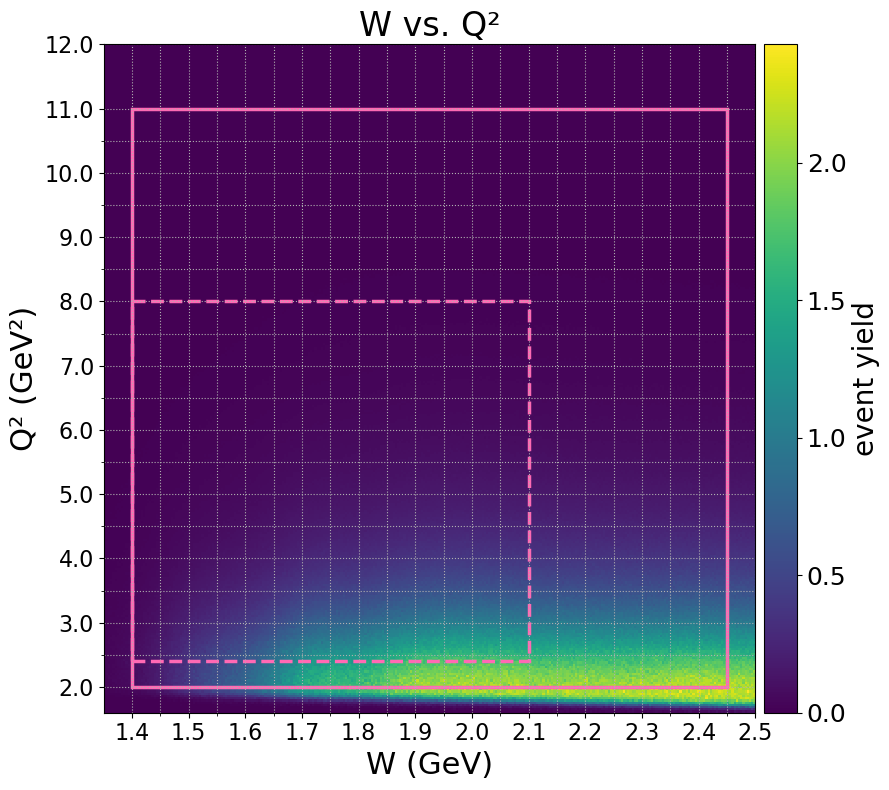

In [ ]:
# Plot W vs Q² histogram
fig, ax = plt.subplots(figsize=(9, 8))

# Plot the accumulated histogram
h = ax.pcolormesh(fine_bin_x, fine_bin_y, wq2_hist.T, cmap="viridis", shading="auto")

# Match the original title and labels
ax.set_title("W vs. Q²", fontsize=24)
ax.set_xlabel("W (GeV)", fontsize=22)
ax.set_ylabel("Q² (GeV²)", fontsize=22)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h, cax=cax)
cb.set_label("event yield", fontsize=20)
cb.ax.tick_params(labelsize=18)

ax.grid(which="both", linestyle=":")

ax.tick_params(axis="both", which="major", labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(np.arange(1.4, 2.51, 0.05), minor=True)
ax.set_yticks(np.arange(2.0, 12.1, 1))
ax.set_yticks(np.arange(2.0, 11.1, 0.5), minor=True)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# ------------------------------------------------------------
# Main analyzed region
# ------------------------------------------------------------

w_min_analyzed = 1.4
w_max_analyzed = 2.45

q2_min_analyzed = 2.0
q2_max_analyzed = 11.0

rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),
    w_max_analyzed - w_min_analyzed,
    q2_max_analyzed - q2_min_analyzed,
    linewidth=2.5,
    edgecolor="hotpink",
    alpha=1.0,
    facecolor="none"
)

# ------------------------------------------------------------
# Krishna analyzed region
# ------------------------------------------------------------

w_min_analyzed_krishna = 1.4
w_max_analyzed_krishna = 2.10

q2_min_analyzed_krishna = 2.4
q2_max_analyzed_krishna = 8.0

rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),
    w_max_analyzed_krishna - w_min_analyzed_krishna,
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,
    linewidth=2.5,
    edgecolor="hotpink",
    alpha=1.0,
    linestyle="--",
    facecolor="none"
)

ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

# w-q2 binned cuts

## set w-q2 values for analysis

In [8]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,13.0]
# q2_bins = np.arange(2.0, 12.1, 0.5)

print("W bins:", len(w_bins) - 1)
print("Q² bins:", len(q2_bins) - 1)
print("Total W/Q² analysis bins:",
      (len(w_bins) - 1) * (len(q2_bins) - 1))

W bins: 22
Q² bins: 11
Total W/Q² analysis bins: 242


## mm2 cuts

### create sigma cuts

In [ ]:
# MM² topology definitions
topologies_mm2 = {
    "excl": {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    "mProt": {"range": (-0.1, 2.5), "fit_window": (0.4, 1.25)},
    "mPip": {"range": (-0.2, 0.2), "fit_window": (-0.2, 0.2)},
    "mPim": {"range": (-0.2, 0.25), "fit_window": (-0.2, 0.25)}
}

# Sigma windows
sigma_factors = [
    (-1.25, 1.25),
    (-1.5, 2.0),
    (-4.0, 4.5)
]

# Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

bins_value = 200
binned_hist_path = Path("MM2_binned_wq2/mm2_cuts")

# ============================================================
# STORAGE
# ============================================================

# Compact histogram arrays.
# We are NOT storing individual events.
mm2_histograms = {}
mm2_fit_parameters = {}

# Create empty histograms for every W/Q²/topology
for w_bin in range(len(w_bins) - 1):

    for q2_bin in range(len(q2_bins) - 1):

        for topo, settings in topologies_mm2.items():

            hist_range = settings["range"]
            counts, edges = np.histogram([], bins=bins_value, range=hist_range)
            mm2_histograms[(w_bin, q2_bin, topo)] = {"counts": counts.astype(np.float64), "edges": edges}

# ============================================================
# PASS 1: Read ROOT file in chunks and accumulate MM²
# histograms.
# ============================================================

total_mm2_events = 0

with tqdm(
    total=entry_stop,
    unit="events",
    desc="Building MM² histograms"
) as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))

        w_bin_indices = np.searchsorted(w_bins, w_values, side="right") - 1
        q2_bin_indices = np.searchsorted(q2_bins, q2_values, side="right") - 1

        valid_wq2 &= (
            (w_bin_indices >= 0)
            & (w_bin_indices < len(w_bins) - 1)
            & (q2_bin_indices >= 0)
            & (q2_bin_indices < len(q2_bins) - 1)
        )

        # ----------------------------------------------------
        # Only events inside the actual analysis W/Q² region
        # are used for the MM² cut histograms.
        # ----------------------------------------------------

        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        valid_indices = np.where(valid_wq2)[0]
        total_mm2_events += len(valid_indices)

        # Process each W/Q² bin represented in this chunk
        chunk_w_bins = w_bin_indices[valid_wq2]
        chunk_q2_bins = q2_bin_indices[valid_wq2]

        for w_bin in np.unique(chunk_w_bins):

            w_mask = chunk_w_bins == w_bin

            for q2_bin in np.unique(chunk_q2_bins[w_mask]):

                local_mask = (w_mask & (chunk_q2_bins == q2_bin))
                original_indices = valid_indices[local_mask]

                # MM² variables for this W/Q² bin
                for topo, settings in topologies_mm2.items():

                    column = f"mm2_{topo}"

                    values = chunk.iloc[original_indices][column].to_numpy()
                    values = values[np.isfinite(values)]

                    if len(values) == 0:
                        continue

                    # Accumulate histogram
                    counts, _ = np.histogram(values, bins=mm2_histograms[(w_bin, q2_bin, topo)]["edges"])
                    mm2_histograms[(w_bin, q2_bin, topo)]["counts"] += counts

        pbar.update(len(chunk))

print()
print("Events inside MM² W/Q² analysis region:", total_mm2_events)

Building MM² histograms:   0%|          | 0/181250322 [00:00<?, ?events/s]


Events inside MM² W/Q² analysis region: 169194571


### plot

In [ ]:
# ============================================================
# FIT MM² HISTOGRAMS AND PLOT MM² CUT WINDOWS
# ============================================================

binned_hist_path = Path("MM2_binned_wq2/mm2_cuts")

def bin_label(bin_idx, bin_edges):

    if bin_idx < len(bin_edges) - 1:
        return (
            f"[{bin_edges[bin_idx]:.2f}, "
            f"{bin_edges[bin_idx + 1]:.2f})"
        )

    return "[out of range)"

def safe_str(label):
    return (label.strip("[]()").replace(",", "_").replace(" ", ""))

# Sigma colors
USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:
    sigma_colors = [
        "limegreen",
        "magenta",
        "darkviolet",
    ]

else:
    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# ============================================================
# FIT EACH ACCUMULATED HISTOGRAM
# ============================================================

total_histograms = (
    (len(w_bins) - 1)
    * (len(q2_bins) - 1)
    * len(topologies_mm2)
)

with tqdm(
    total=total_histograms,
    unit="hist",
    desc="Fitting and saving MM² histograms"
) as pbar:
    
    for w_bin in range(len(w_bins) - 1):

        for q2_bin in range(len(q2_bins) - 1):

            # Labels used in the original Cell A filenames
            w_label = bin_label(w_bin, w_bins)
            q2_label = bin_label(q2_bin, q2_bins)

            for topo, settings in topologies_mm2.items():

                key = (w_bin, q2_bin, topo)

                counts = mm2_histograms[key]["counts"]
                edges = mm2_histograms[key]["edges"]
                bin_centers = (edges[:-1] + edges[1:]) / 2.0

                # Histogram range
                x_min, x_max = settings["range"]

                # Number of events in histogram
                n_events = counts.sum()

                # Fit window
                fit_window = settings["fit_window"]
                fit_window_left, fit_window_right = fit_window
                fit_mask = ((bin_centers >= fit_window_left) & (bin_centers <= fit_window_right))

                # Initialize fit values
                amp_fit = None
                mean_fit = None
                sigma_fit = None

                try:
                    if not np.any(fit_mask):
                        raise ValueError("No histogram bins in fit window.")

                    local_values = counts[fit_mask]
                    local_centers = bin_centers[fit_mask]

                    if local_values.sum() == 0:
                        raise ValueError("No counts in fit window.")

                    local_peak_idx = np.argmax(local_values)
                    global_peak_idx = np.where(fit_mask)[0][local_peak_idx]
                    peak_x = bin_centers[global_peak_idx]

                    x_fit = local_centers
                    y_fit = local_values

                    if len(x_fit) < 3:
                        raise ValueError("Insufficient points for Gaussian fit.")

                    amp_guess = float(y_fit.max())
                    mean_guess = float(peak_x)
                    sigma_guess = max(1e-6, 0.25 * (fit_window_right - fit_window_left))

                    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[amp_guess, mean_guess, sigma_guess],maxfev=20000)
                    amp_fit = popt[0]
                    mean_fit = popt[1]
                    sigma_fit = abs(popt[2])


                except Exception as e:
                    print(f"Skipping bad fit -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")

                # Save fit parameters
                mm2_fit_parameters[key] = {
                    "mean": mean_fit,
                    "sigma": sigma_fit,
                    "amplitude": amp_fit
                }

                # PLOT
                plt.figure(figsize=(11, 7))

                # All events
                plt.step(bin_centers, counts, where="mid", color="black", linewidth=0.8, alpha=0.8, label=f"all events (N={n_events:,})")

                # Gaussian fit
                if (
                    amp_fit is not None
                    and sigma_fit is not None
                    and mean_fit is not None
                ):

                    x_dense = np.linspace(max(x_min, fit_window_left), min(x_max, fit_window_right), 1000)
                    y_dense = gaussian(x_dense, amp_fit, mean_fit, sigma_fit)

                    plt.plot(x_dense, y_dense, color="blue", alpha=0.6, linewidth=1.0, label="gaussian fit")

                    # Fit mean
                    plt.axvline(mean_fit, color="blue", linestyle="--", alpha=0.6, linewidth=1.0, label=f"peak fit = {mean_fit:.4f}")

                    # MM² CUT WINDOWS
                    for i, (left_sigma, right_sigma) in enumerate(sigma_factors):

                        left = (mean_fit + left_sigma * sigma_fit)
                        right = (mean_fit + right_sigma * sigma_fit)

                        # Number of events inside this cut.
                        #
                        # We do NOT have the original event-level
                        # DataFrame anymore, so this is calculated
                        # directly from the accumulated histogram.

                        cut_mask = ((bin_centers >= left) & (bin_centers <= right))
                        n_inside = counts[cut_mask].sum()

                        color = sigma_colors[i]
                        lw = 1.2
                        alpha = 0.9

                        plt.axvline(left, color=color, linestyle="-", linewidth=lw, alpha=alpha)
                        plt.axvline(right, color=color, linestyle="-", linewidth=lw, alpha=alpha)

                        plt.plot(
                            [],
                            [],
                            color=color,
                            linestyle="-",
                            linewidth=lw,
                            alpha=alpha,
                            label=(
                                f"{left_sigma:+.2f}σ to "
                                f"{right_sigma:+.2f}σ "
                                f"(N={n_inside:,})"
                            )
                        )

                # Title and labels
                plt.title(f"{topo} MM²: "f"W {w_label}, "f"Q² {q2_label}", fontsize=25)
                plt.xlabel("MM² [GeV²]", fontsize=20)
                plt.xlim(x_min, x_max)
                plt.xticks(fontsize=15)
                plt.yticks(fontsize=15)
                plt.grid(alpha=0.5)
                plt.legend(fontsize=14, loc="upper left")

                outdir = (hist_base_path / binned_hist_path / f"mm2cuts_{topo}")
                outdir.mkdir(parents=True, exist_ok=True)

                fname = (outdir / (f"mm2_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"))

                plt.savefig(fname, dpi=300)
                plt.close()
                pbar.update(1)

print("MM² histogram fitting and cut plots complete.")

Fitting and saving MM² histograms:   0%|          | 0/968 [00:00<?, ?hist/s]

Skipping bad fit -> excl, W-bin 20, Q2-bin 10: Optimal parameters not found: Number of calls to function has reached maxfev = 20000.
Skipping bad fit -> excl, W-bin 21, Q2-bin 10: No counts in fit window.
Skipping bad fit -> mProt, W-bin 21, Q2-bin 10: Optimal parameters not found: Number of calls to function has reached maxfev = 20000.
MM² histogram fitting and cut plots complete.


## theta cuts

### create sigma cuts

In [ ]:
# ============================================================
# THETA CUT — PART 1
# Memory-safe histogram accumulation from ROOT
# ============================================================

topologies_theta = {
    "prot": {
        "column": "prot_theta_angle_btwn_P",
        "range": (-1, 25)
    },
    "pip": {
        "column": "pip_theta_angle_btwn_P",
        "range": (-1, 25)
    },
    "pim": {
        "column": "pim_theta_angle_btwn_P",
        "range": (-1, 25)
    },
}

theta_sigma_factors = (0.25, 1.5, 4.0)

theta_bins_value = 200

# Store only compact histogram arrays.
theta_histograms = {}

for w_bin in range(len(w_bins) - 1):
    for q2_bin in range(len(q2_bins) - 1):

        for topo, settings in topologies_theta.items():

            hist_range = settings["range"]

            counts, edges = np.histogram([], bins=theta_bins_value, range=hist_range)

            theta_histograms[(w_bin, q2_bin, topo)] = {
                "counts": counts.astype(np.float64),
                "edges": edges
            }

total_theta_events = 0

with tqdm(
    total=entry_stop,
    unit="events",
    desc="Building theta histograms"
) as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))

        # Determine W and Q² analysis-bin indices.
        w_bin_indices = (np.searchsorted(w_bins, w_values, side="right") - 1)
        q2_bin_indices = (np.searchsorted(q2_bins, q2_values, side="right") - 1)

        valid_wq2 &= (
            (w_bin_indices >= 0)
            & (w_bin_indices < len(w_bins) - 1)
            & (q2_bin_indices >= 0)
            & (q2_bin_indices < len(q2_bins) - 1)
        )

        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        valid_indices = np.where(valid_wq2)[0]
        total_theta_events += len(valid_indices)

        chunk_w_bins = w_bin_indices[valid_wq2]
        chunk_q2_bins = q2_bin_indices[valid_wq2]

        # Only process W/Q² bins actually present in this chunk.
        for w_bin in np.unique(chunk_w_bins):

            w_mask = chunk_w_bins == w_bin

            for q2_bin in np.unique(chunk_q2_bins[w_mask]):

                local_mask = (w_mask & (chunk_q2_bins == q2_bin))
                original_indices = valid_indices[local_mask]

                for topo, settings in topologies_theta.items():

                    column = settings["column"]
                    values = (chunk.iloc[original_indices][column].to_numpy())
                    values = values[np.isfinite(values)]

                    if len(values) == 0:
                        continue

                    counts, _ = np.histogram(values, bins=theta_histograms[(w_bin, q2_bin, topo)]["edges"])
                    theta_histograms[(w_bin, q2_bin, topo)]["counts"] += counts

        pbar.update(len(chunk))

print("Events inside theta W/Q² analysis region:", total_theta_events)

Building theta histograms:   0%|          | 0/181250322 [00:00<?, ?events/s]

Events inside theta W/Q² analysis region: 169194571


### plot

In [ ]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

binned_hist_path = Path("MM2_binned_wq2/theta_cuts")

def bin_label(bin_idx, bin_edges):

    if bin_idx < len(bin_edges) - 1:
        return (
            f"[{bin_edges[bin_idx]:.2f}, "
            f"{bin_edges[bin_idx + 1]:.2f})"
        )

    return "[out of range)"

def safe_str(label):
    return (label.strip("[]()").replace(",", "_").replace(" ", ""))

theta_fit_parameters = {}

# Progress bar
total_theta_histograms = (
    (len(w_bins) - 1)
    * (len(q2_bins) - 1)
    * len(topologies_theta)
)

with tqdm(
    total=total_theta_histograms,
    unit="hist",
    desc="Fitting and saving theta histograms"
) as pbar:

    for w_bin in range(len(w_bins) - 1):

        for q2_bin in range(len(q2_bins) - 1):

            w_label = bin_label(w_bin, w_bins)
            q2_label = bin_label(q2_bin, q2_bins)

            for topo, settings in topologies_theta.items():

                key = (w_bin, q2_bin, topo)

                counts = theta_histograms[key]["counts"]
                edges = theta_histograms[key]["edges"]
                bin_centers = (0.5 * (edges[:-1] + edges[1:]))

                x_min, x_max = settings["range"]
                n_events = counts.sum()

                # Determine peak
                peak_index = np.argmax(counts)
                peak_value = bin_centers[peak_index]
                peak_height = counts[peak_index]

                # Determine FWHM
                half_max = peak_height / 2.0
                above_half = counts >= half_max

                if np.any(above_half):

                    fwhm_indices = np.where(above_half)[0]
                    left_index = fwhm_indices[0]
                    right_index = fwhm_indices[-1]
                    fwhm = (bin_centers[right_index] - bin_centers[left_index])

                else:
                    fwhm = np.nan

                # ------------------------------------------------
                # Convert FWHM to Gaussian sigma
                #
                # FWHM = 2.355 sigma
                # ------------------------------------------------

                if np.isfinite(fwhm) and fwhm > 0:
                    sigma_fit = fwhm / 2.355
                else:
                    sigma_fit = np.nan
                mean_fit = peak_value

                # Store fit information
                theta_fit_parameters[key] = {
                    "mean": mean_fit,
                    "sigma": sigma_fit,
                    "peak": peak_value,
                    "fwhm": fwhm,
                    "amplitude": peak_height
                }

                # Plot
                plt.figure(figsize=(11, 7))
                plt.step(bin_centers, counts, where="mid", color="black", linewidth=0.8, alpha=0.8, label=f"all events (N={int(n_events):,})")

                # Gaussian representation
                if (np.isfinite(sigma_fit) and sigma_fit > 0):

                    x_dense = np.linspace(x_min, x_max, 1000)
                    gaussian_values = gaussian(x_dense, peak_height, mean_fit, sigma_fit)

                    plt.plot(x_dense, gaussian_values, color="blue", alpha=0.6, linewidth=1.0, label="gaussian fit")
                    plt.axvline(mean_fit, color="blue", linestyle="--", alpha=0.6, linewidth=1.0, label=f"peak = {mean_fit:.3f}°")

                    USE_MANUAL_COLORS = True

                    if USE_MANUAL_COLORS:
                        sigma_colors = [
                            "limegreen",
                            "magenta",
                            "darkviolet",
                        ]
                    else:
                        cmap = plt.cm.rainbow_r
                        sigma_colors = cmap(np.linspace(0, 1, len(theta_sigma_factors)))

                    for i, sigma_factor in enumerate(theta_sigma_factors):

                        upper_cut = (mean_fit + sigma_factor * sigma_fit)
                        cut_mask = (bin_centers <= upper_cut)
                        n_inside = counts[cut_mask].sum()

                        color = sigma_colors[i]

                        plt.axvline(upper_cut, color=color, linestyle="--", alpha=0.9, linewidth=1.2)

                        plt.plot(
                            [],
                            [],
                            color=color,
                            linestyle="--",
                            linewidth=1.2,
                            label=(
                                f"{sigma_factor:.2f}σ "
                                f"upper cut "
                                f"(N={int(n_inside):,})"
                            )
                        )

                # Formatting
                plt.title(f"{topo} θ angle: W {w_label}, Q² {q2_label}", fontsize=25)
                plt.xlabel(r"$\theta_{\mathrm{miss-meas}}$ [degrees]", fontsize=20)
                plt.xlim(x_min, x_max)
                plt.xticks(fontsize=15)
                plt.yticks(fontsize=15)
                plt.grid(alpha=0.5)
                plt.legend(fontsize=14, loc="upper right")

                outdir = (hist_base_path / binned_hist_path / f"thetacuts_{topo}")
                outdir.mkdir(parents=True, exist_ok=True)

                fname = (outdir / (f"theta_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"))

                plt.savefig(fname, dpi=300)
                plt.close()
                pbar.update(1)

print("Theta histogram fitting and cut plots complete.")

Fitting and saving theta histograms:   0%|          | 0/726 [00:00<?, ?hist/s]

Theta histogram fitting and cut plots complete.


## momentum cuts

### create sigma cuts

In [ ]:
# Momentum topology definitions
topologies_momentum = {
    "prot": {
        "missing": "prot_mom_miss",
        "measured": "prot_mom_meas",
        "range": (-1, 2)
    },

    "pip": {
        "missing": "pip_mom_miss",
        "measured": "pip_mom_meas",
        "range": (-1, 2)
    },

    "pim": {
        "missing": "pim_mom_miss",
        "measured": "pim_mom_meas",
        "range": (-1, 2)
    }
}

# Momentum sigma choices
mom_sigma_factors = (1.0, 2.0, 4.0)

mom_bins_value = 200

# Compact histogram arrays only.
# Individual momentum values are NOT stored.
momentum_histograms = {}

# Create empty histograms for every W/Q²/topology
for w_bin in range(len(w_bins) - 1):

    for q2_bin in range(len(q2_bins) - 1):

        for topo, settings in topologies_momentum.items():

            hist_range = settings["range"]
            counts, edges = np.histogram([], bins=mom_bins_value, range=hist_range)

            momentum_histograms[(w_bin, q2_bin, topo)] = {
                "counts": counts.astype(np.float64),
                "edges": edges
            }

# ============================================================
# PASS 1: Read ROOT file in chunks and accumulate momentum
# histograms.
# ============================================================

total_momentum_events = 0

with tqdm(
    total=entry_stop,
    unit="events",
    desc="Building momentum histograms"
) as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        # Determine W/Q² analysis bin
        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))

        w_bin_indices = np.searchsorted(w_bins, w_values, side="right") - 1
        q2_bin_indices = np.searchsorted(q2_bins, q2_values, side="right") - 1

        valid_wq2 &= (
            (w_bin_indices >= 0)
            & (w_bin_indices < len(w_bins) - 1)
            & (q2_bin_indices >= 0)
            & (q2_bin_indices < len(q2_bins) - 1)
        )

        # Skip chunks with no events in W/Q² region
        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        valid_indices = np.where(valid_wq2)[0]
        total_momentum_events += len(valid_indices)

        # W/Q² bins represented in this chunk
        chunk_w_bins = w_bin_indices[valid_wq2]
        chunk_q2_bins = q2_bin_indices[valid_wq2]

        for w_bin in np.unique(chunk_w_bins):

            w_mask = (chunk_w_bins == w_bin)

            for q2_bin in np.unique(chunk_q2_bins[w_mask]):

                local_mask = (w_mask & (chunk_q2_bins == q2_bin))
                original_indices = (valid_indices[local_mask])

                # Momentum variables
                for topo, settings in (topologies_momentum.items()):

                    missing_column = (settings["missing"])
                    measured_column = (settings["measured"])

                    missing = chunk.iloc[original_indices][missing_column].to_numpy()
                    measured = chunk.iloc[original_indices][measured_column].to_numpy()

                    delta_p = (missing - measured)
                    delta_p = delta_p[np.isfinite(delta_p)]

                    if len(delta_p) == 0:
                        continue

                    # Accumulate histogram
                    counts, _ = np.histogram(delta_p, bins=momentum_histograms[(w_bin, q2_bin, topo)]["edges"])
                    momentum_histograms[(w_bin, q2_bin, topo)]["counts"] += counts

        pbar.update(len(chunk))

print()
print("Events inside momentum W/Q² analysis region:", total_momentum_events)

Building momentum histograms:   0%|          | 0/181250322 [00:00<?, ?events/s]


Events inside momentum W/Q² analysis region: 169194571


### plot

In [ ]:
binned_hist_path = Path("MM2_binned_wq2/momentum_cuts")

def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def bin_label(bin_idx, bin_edges):

    if bin_idx < len(bin_edges) - 1:

        return (
            f"[{bin_edges[bin_idx]:.2f}, "
            f"{bin_edges[bin_idx + 1]:.2f})"
        )

    return "[out of range)"

def safe_str(label):
    return (label.strip("[]()").replace(",", "_").replace(" ", ""))

USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:

    sigma_colors = [
        "limegreen",
        "magenta",
        "darkviolet",
    ]

else:

    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(mom_sigma_factors)))

momentum_fit_parameters = {}

# ============================================================
# FIT EACH ACCUMULATED HISTOGRAM
# ============================================================

total_histograms = (
    (len(w_bins) - 1)
    * (len(q2_bins) - 1)
    * len(topologies_momentum)
)

with tqdm(
    total=total_histograms,
    unit="hist",
    desc="Fitting and saving momentum histograms"
) as pbar:

    for w_bin in range(len(w_bins) - 1):

        for q2_bin in range(len(q2_bins) - 1):

            # Labels
            w_label = bin_label(w_bin, w_bins)
            q2_label = bin_label(q2_bin, q2_bins)

            for topo, settings in (topologies_momentum.items()):

                key = (w_bin, q2_bin, topo)
                counts = momentum_histograms[key]["counts"]
                edges = momentum_histograms[key]["edges"]
                bin_centers = (edges[:-1] + edges[1:]) / 2.0
                x_min, x_max = (settings["range"])
                n_events = counts.sum()

                # Fit region
                fit_window_left = -0.5
                fit_window_right = 0.3

                fit_mask = ((bin_centers >= fit_window_left) & (bin_centers <= fit_window_right))

                amp_fit = None
                mean_fit = None
                sigma_fit = None

                # Gaussian fit
                try:

                    if not np.any(fit_mask):
                        raise ValueError("No histogram bins in fit window.")

                    local_values = counts[fit_mask]
                    local_centers = bin_centers[fit_mask]
                    
                    if local_values.sum() == 0:
                        raise ValueError("No counts in fit window.")

                    local_peak_idx = np.argmax(local_values)
                    global_peak_idx = np.where(fit_mask)[0][local_peak_idx]
                    peak_x = bin_centers[global_peak_idx]

                    x_fit = local_centers
                    y_fit = local_values

                    if len(x_fit) < 3:
                        raise ValueError("Insufficient points for Gaussian fit.")

                    amp_guess = float(y_fit.max())
                    mean_guess = float(peak_x)
                    sigma_guess = 0.1

                    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[amp_guess, mean_guess, sigma_guess], maxfev=20000)

                    amp_fit = popt[0]
                    mean_fit = popt[1]
                    sigma_fit = abs(popt[2])

                except Exception as e:
                    print(f"Skipping bad fit -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")

                # Save fit parameters
                momentum_fit_parameters[key] = {
                    "mean": mean_fit,
                    "sigma": sigma_fit,
                    "amplitude": amp_fit
                }

                # PLOT
                plt.figure(figsize=(11, 7))

                # All events
                plt.step(bin_centers, counts, where="mid", color="black", linewidth=0.8, alpha=0.8, label=(f"all events (N={n_events:,})"))

                # Gaussian fit
                if (
                    amp_fit is not None
                    and sigma_fit is not None
                    and mean_fit is not None
                ):

                    x_dense = np.linspace(x_min, x_max, 1000)
                    y_dense = gaussian(x_dense, amp_fit, mean_fit, sigma_fit)

                    plt.plot(x_dense, y_dense, color="blue", alpha=0.6, linewidth=1.0, label="gaussian fit")

                    # Fit mean
                    plt.axvline(mean_fit, color="blue", linestyle="--", alpha=0.6, linewidth=1.0, label=(f"peak fit = {mean_fit:.4f}"))

                    # =================================================
                    # MOMENTUM CUT WINDOWS
                    # =================================================

                    for i, sigma_factor in enumerate(mom_sigma_factors):

                        left = (mean_fit - sigma_factor * sigma_fit)
                        right = (mean_fit + sigma_factor * sigma_fit)

                        # Number of events inside cut
                        cut_mask = ((bin_centers >= left) & (bin_centers <= right))
                        n_inside = counts[cut_mask].sum()

                        # Same colors as MM²
                        color = sigma_colors[i]

                        plt.axvline(left, color=color, linestyle="-", linewidth=1.2, alpha=0.9)
                        plt.axvline(right, color=color, linestyle="-", linewidth=1.2, alpha=0.9)
                        plt.plot([], [], color=color, linestyle="-", linewidth=1.2, alpha=0.9, label=(f"±{sigma_factor:.1f}σ (N={n_inside:,})"))

                # Title and labels
                plt.title(f"{topo} momentum difference: W {w_label}, Q² {q2_label}", fontsize=25)

                plt.xlabel(
                    r"$\Delta p = "
                    r"p_{\mathrm{miss}} - "
                    r"p_{\mathrm{meas}}$ [GeV]",
                    fontsize=20
                )

                plt.xlim(x_min, x_max)
                plt.xticks(fontsize=15)
                plt.yticks(fontsize=15)
                plt.grid(alpha=0.5)
                plt.legend(fontsize=14, loc="upper left")

                outdir = (hist_base_path / binned_hist_path / f"momentumcuts_{topo}")
                outdir.mkdir(parents=True, exist_ok=True)

                fname = (outdir / (f"momentum_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"))

                plt.savefig(fname, dpi=300)
                plt.close()
                pbar.update(1)

print("Momentum histogram fitting and cut plots complete.")

Fitting and saving momentum histograms:   0%|          | 0/726 [00:00<?, ?hist/s]

Skipping bad fit -> pim, W-bin 21, Q2-bin 10: No counts in fit window.
Momentum histogram fitting and cut plots complete.


## enhanced signal

### apply selection criteria

In [ ]:
# ============================================================
# ENHANCED SIGNAL
# Memory-safe ROOT version
#
# Logic follows the original select_signal_events() exactly:
#
#   1. Start from ALL events in the W,Q² bin.
#
#   2. For a given primary MM² topology:
#        - DO NOT cut the primary topology's MM².
#        - Apply MM² sigma cuts to the OTHER MM² topologies.
#
#   3. If enabled:
#        - Apply theta cuts to prot, pip, pim.
#
#   4. If enabled:
#        - Apply momentum cuts to prot, pip, pim.
#
#   5. Histogram the PRIMARY MM² distribution after those cuts.
#
# ============================================================

if "entry_stop" not in globals():
    raise RuntimeError(
        "entry_stop is not defined. "
        "Run the ROOT setup cell first."
    )

if "full_tree" not in globals():
    raise RuntimeError(
        "full_tree is not defined. "
        "Run the ROOT setup cell first."
    )

if "STEP_SIZE" not in globals():
    raise RuntimeError(
        "STEP_SIZE is not defined. "
        "Run the ROOT setup cell first."
    )

# ------------------- sigma control -------------------
SCAN_MM2_SIGMA = False          # False -> use FIXED_MM2_SIGMA_SIG
FIXED_MM2_SIGMA_SIG = (-4.0, 4.5)

SCAN_THETA_SIGMA = False        # False -> use FIXED_THETA_SIGMA_SIG
FIXED_THETA_SIGMA_SIG = 4.0

SCAN_MOMENTUM_SIGMA = False     # False -> use FIXED_MOMENTUM_SIGMA_SIG
FIXED_MOMENTUM_SIGMA_SIG = 4.0

USE_MM2 = True                  # independent of scan or fixed, can turn cuts on/off
USE_THETA = True
USE_MOMENTUM = True

def build_cut_tag():

    tags = []

    if USE_MM2:
        tags.append("mm2")

    if USE_THETA:
        tags.append("theta")

    if USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")

    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")

    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"
    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2" / "enhancedsignal" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

mm2_topos = ["excl", "mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

# Required sigma factors
# These should already exist from the MM²/theta/momentum cells.
if USE_MM2 and "sigma_factors" not in globals():
    raise RuntimeError(
        "sigma_factors is not defined. "
        "Run the MM² setup cell first."
    )

if USE_THETA and "theta_sigma_factors" not in globals():
    raise RuntimeError(
        "theta_sigma_factors is not defined. "
        "Run the theta setup cell first."
    )

if USE_MOMENTUM and "mom_sigma_factors" not in globals():
    raise RuntimeError(
        "mom_sigma_factors is not defined. "
        "Run the momentum setup cell first."
    )

# Required fit parameters
if USE_MM2 and "mm2_fit_parameters" not in globals():
    raise RuntimeError(
        "mm2_fit_parameters is not defined. "
        "Run the MM² fitting cell first."
    )

if USE_THETA and "theta_fit_parameters" not in globals():
    raise RuntimeError(
        "theta_fit_parameters is not defined. "
        "Run the theta fitting cell first."
    )

if USE_MOMENTUM and "momentum_fit_parameters" not in globals():
    raise RuntimeError(
        "momentum_fit_parameters is not defined. "
        "Run the momentum fitting cell first."
    )

# Determine sigma values to use
if USE_MM2:
    if SCAN_MM2_SIGMA:
        mm2_sigmas_to_use = sigma_factors
    else:
        mm2_sigmas_to_use = [FIXED_MM2_SIGMA_SIG]

else:
    mm2_sigmas_to_use = [None]

if USE_THETA:
    if SCAN_THETA_SIGMA:
        theta_sigmas_to_use = theta_sigma_factors
    else:
        theta_sigmas_to_use = [FIXED_THETA_SIGMA_SIG]
else:
    theta_sigmas_to_use = [None]

if USE_MOMENTUM:
    if SCAN_MOMENTUM_SIGMA:
        momentum_sigmas_to_use = mom_sigma_factors
    else:
        momentum_sigmas_to_use = [FIXED_MOMENTUM_SIGMA_SIG]
else:
    momentum_sigmas_to_use = [None]

# All sigma combinations
sigma_combos = list(itertools.product(mm2_sigmas_to_use, theta_sigmas_to_use, momentum_sigmas_to_use))

# Print configuration
print("============================================================")
print("ENHANCED SIGNAL CONFIGURATION")
print("============================================================")

print(f"MM² cuts:      {'ON' if USE_MM2 else 'OFF'}")
if USE_MM2:
    print(f"  MM² sigma: {'SCAN' if SCAN_MM2_SIGMA else FIXED_MM2_SIGMA_SIG}")

print(f"Theta cuts:    {'ON' if USE_THETA else 'OFF'}")
if USE_THETA:
    print(f"  Theta sigma: {'SCAN' if SCAN_THETA_SIGMA else FIXED_THETA_SIGMA_SIG}")

print(f"Momentum cuts: {'ON' if USE_MOMENTUM else 'OFF'}")
if USE_MOMENTUM:
    print(f"  Momentum sigma: {'SCAN' if SCAN_MOMENTUM_SIGMA else FIXED_MOMENTUM_SIGMA_SIG}")

print()
print(f"Number of sigma combinations: {len(sigma_combos)}")
print()
print(f"Output directory:")
print(binned_mm2_plot_path)
print("============================================================")

# Helper function:
# get Gaussian fit parameters
def get_fit_parameters(fit_dict, w_bin, q2_bin, topo):

    params = fit_dict.get((w_bin, q2_bin, topo))

    if params is None:
        return None, None

    mean_fit = params.get("mean")
    sigma_fit = params.get("sigma")

    if (
        mean_fit is None
        or sigma_fit is None
        or not np.isfinite(mean_fit)
        or not np.isfinite(sigma_fit)
        or sigma_fit <= 0
    ):
        return None, None

    return (float(mean_fit), float(sigma_fit))

# ============================================================
# Helper function:
# MM² selection for ONE topology
#
# This applies the MM² cut to an "other" topology.
# ============================================================

def build_mm2_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, topo, sigma_range):

    mask = np.zeros(len(chunk), dtype=bool)

    if sigma_range is None:
        return valid_wq2.copy()

    left_sigma, right_sigma = sigma_range
    values = chunk[f"mm2_{topo}"].to_numpy()
    valid = (valid_wq2 & np.isfinite(values))
    valid_indices = np.where(valid)[0]

    for idx in valid_indices:

        w_bin = w_bin_indices[idx]
        q2_bin = q2_bin_indices[idx]

        mean_fit, sigma_fit = get_fit_parameters(mm2_fit_parameters, w_bin, q2_bin, topo)

        if mean_fit is None:
            continue

        left = (mean_fit + left_sigma * sigma_fit)
        right = (mean_fit + right_sigma * sigma_fit)

        if (values[idx] >= left and values[idx] <= right):
            mask[idx] = True

    return mask

# ============================================================
# Helper function:
# theta selection
#
# All three particles must pass.
# ============================================================

def build_theta_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, sigma):

    mask = valid_wq2.copy()\

    theta_columns = {
        "prot": "prot_theta_angle_btwn_P",
        "pip": "pip_theta_angle_btwn_P",
        "pim": "pim_theta_angle_btwn_P",
    }

    for topo, column in theta_columns.items():

        values = chunk[column].to_numpy()
        particle_mask = np.zeros(len(chunk), dtype=bool)
        valid = (valid_wq2 & np.isfinite(values))
        valid_indices = np.where(valid)[0]

        for idx in valid_indices:

            w_bin = w_bin_indices[idx]
            q2_bin = q2_bin_indices[idx]

            mean_fit, sigma_fit = get_fit_parameters(theta_fit_parameters, w_bin, q2_bin, topo)

            if mean_fit is None:
                continue

            upper_cut = (mean_fit + sigma * sigma_fit)

            if values[idx] <= upper_cut:
                particle_mask[idx] = True

        mask &= particle_mask

    return mask

# ============================================================
# Helper function:
# momentum selection
#
# All three particles must pass.
#
# delta_p = missing - measured
# ============================================================

def build_momentum_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, sigma):

    mask = valid_wq2.copy()

    momentum_columns = {
        "prot": (
            "prot_mom_miss",
            "prot_mom_meas"
        ),

        "pip": (
            "pip_mom_miss",
            "pip_mom_meas"
        ),

        "pim": (
            "pim_mom_miss",
            "pim_mom_meas"
        ),
    }

    for topo, (missing_column, measured_column) in momentum_columns.items():

        missing = chunk[missing_column].to_numpy()
        measured = chunk[measured_column].to_numpy()
        delta_p = (missing - measured)

        particle_mask = np.zeros(len(chunk), dtype=bool)
        valid = (valid_wq2 & np.isfinite(delta_p))
        valid_indices = np.where(valid)[0]

        for idx in valid_indices:

            w_bin = w_bin_indices[idx]
            q2_bin = q2_bin_indices[idx]

            mean_fit, sigma_fit = get_fit_parameters(momentum_fit_parameters, w_bin, q2_bin, topo)

            if mean_fit is None:
                continue

            left = (mean_fit - sigma * sigma_fit)
            right = (mean_fit + sigma * sigma_fit)

            if (delta_p[idx] >= left and delta_p[idx] <= right):
                particle_mask[idx] = True

        mask &= particle_mask

    return mask

# ============================================================
# Histogram storage
#
# all_histograms:
#   completely uncut MM² distributions
#
# signal_histograms:
#   distributions after the enhanced signal cuts
# ============================================================

all_histograms = {}
signal_histograms = {}

for w_bin in range(len(w_bins) - 1):

    for q2_bin in range(len(q2_bins) - 1):

        for topo in mm2_topos:

            hist_range = (topologies_mm2[topo]["range"])

            empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

            all_histograms[(w_bin, q2_bin, topo)] = {
                "counts": empty_counts.astype(
                    np.float64
                ),
                "edges": edges
            }

            for combo_index in range(len(sigma_combos)):

                signal_histograms[(w_bin, q2_bin, topo, combo_index)] = {
                    "counts": np.zeros(
                        bins_value,
                        dtype=np.float64
                    ),
                    "edges": edges
                }

# ============================================================
# Process ROOT file
# ============================================================

with tqdm(total=entry_stop, unit="events", desc="Building enhanced signal") as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))

        w_bin_indices = (np.searchsorted(w_bins, w_values, side="right") - 1)
        q2_bin_indices = (np.searchsorted(q2_bins, q2_values, side="right") - 1)

        valid_wq2 &= (

            (w_bin_indices >= 0)

            & (
                w_bin_indices
                < len(w_bins) - 1
            )

            & (q2_bin_indices >= 0)

            & (
                q2_bin_indices
                < len(q2_bins) - 1
            )
        )

        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        weights = chunk["weight"].to_numpy()

        # ====================================================
        # ALL-EVENT HISTOGRAMS
        # No cuts whatsoever.
        # ====================================================

        for primary_topo in mm2_topos:

            primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
            valid_primary = (valid_wq2 & np.isfinite(primary_values))

            selected_indices = np.where(valid_primary)[0]

            if len(selected_indices) == 0:
                continue

            selected_w_bins = (w_bin_indices[selected_indices])
            selected_q2_bins = (q2_bin_indices[selected_indices])

            for w_bin in np.unique(selected_w_bins):

                w_selection = (selected_w_bins == w_bin)
                indices_for_w = (selected_indices[w_selection])
                q2_for_w = (selected_q2_bins[w_selection])

                for q2_bin in np.unique(q2_for_w):

                    q2_selection = (q2_for_w == q2_bin)
                    final_indices = (indices_for_w[q2_selection])
                    values = (primary_values[final_indices])
                    event_weights = (weights[final_indices])

                    counts, _ = np.histogram(values, bins=bins_value, range=(topologies_mm2[primary_topo]["range"]), weights=event_weights)

                    all_histograms[(w_bin, q2_bin, primary_topo)]["counts"] += counts

        # ====================================================
        # SIGNAL HISTOGRAMS
        # ====================================================

        for combo_index, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

            # Theta mask
            if USE_THETA:
                theta_mask = build_theta_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, theta_sigma)
            else:
                theta_mask = valid_wq2.copy()

            # Momentum mask
            if USE_MOMENTUM:
                momentum_mask = (build_momentum_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, momentum_sigma))
            else:
                momentum_mask = valid_wq2.copy()

            # Common theta + momentum selection
            common_mask = (theta_mask & momentum_mask)

            # =================================================
            # Loop over PRIMARY MM² topology
            # =================================================

            for primary_topo in mm2_topos:
                primary_mask = (common_mask.copy())

                # =================================================
                # MM² cuts
                # ONLY OTHER TOPOLOGIES ARE CUT.
                # The primary topology is deliberately skipped.
                # =================================================

                if USE_MM2:
                    for other_topo in mm2_topos:
                        if (other_topo == primary_topo):
                            continue

                        other_mask = (build_mm2_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, other_topo, mm2_sigma))
                        primary_mask &= (other_mask)

                # =================================================
                # Primary MM² values
                #
                # No MM² cut is applied to these values.
                # =================================================

                primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
                primary_mask &= (np.isfinite(primary_values))

                # Find selected events
                selected_indices = np.where(primary_mask)[0]

                if len(selected_indices) == 0:
                    continue

                selected_w_bins = (w_bin_indices[selected_indices])
                selected_q2_bins = (q2_bin_indices[selected_indices])

                # Fill selected signal histogram
                for w_bin in np.unique(selected_w_bins):

                    w_selection = (selected_w_bins == w_bin)
                    indices_for_w = (selected_indices[w_selection])
                    q2_for_w = (selected_q2_bins[w_selection])

                    for q2_bin in np.unique(q2_for_w):

                        q2_selection = (q2_for_w == q2_bin)
                        final_indices = (indices_for_w[q2_selection])
                        values = (primary_values[final_indices])
                        event_weights = (weights[final_indices])

                        counts, _ = np.histogram(values, bins=bins_value, range=(topologies_mm2[primary_topo]["range"]), weights=event_weights)
                        signal_histograms[(w_bin, q2_bin, primary_topo, combo_index)]["counts"] += counts

        pbar.update(len(chunk))

print()
print("Enhanced signal histograms accumulated successfully.")

ENHANCED SIGNAL CONFIGURATION
MM² cuts:      ON
  MM² sigma:  (-4.0, 4.5)
Theta cuts:    ON
  Theta sigma: 4.0
Momentum cuts: ON
  Momentum sigma: 4.0

Number of sigma combinations: 1

Output directory:
/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/simulationTEST/spring19_inb_50nA/EXCL_topology/MM2_binned_wq2/enhancedsignal/mm2_theta_momentum_cuts__fixedSigma


Building enhanced signal:   0%|          | 0/181250322 [00:00<?, ?events/s]


Enhanced signal histograms accumulated successfully.


### plot

In [ ]:
total_hists = ((len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos))

# Sigma colors
USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:

    sigma_colors = [
        "magenta",
        "magenta",
        "darkviolet",
    ]

else:
    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, max(len(sigma_combos), 2)))

# Save plots
with tqdm(total=total_hists, desc="Saving enhanced signal histograms", unit="hist") as pbar:

    for w_bin in range(len(w_bins) - 1):

        w_min = w_bins[w_bin]
        w_max = w_bins[w_bin + 1]

        w_label = (f"[{w_min:.2f}, {w_max:.2f})")

        for q2_bin in range(len(q2_bins) - 1):

            q2_min = q2_bins[q2_bin]
            q2_max = q2_bins[q2_bin + 1]

            q2_label = (f"[{q2_min:.2f}, {q2_max:.2f})")

            for topo in mm2_topos:

                # All-event histogram
                all_data = all_histograms[(w_bin, q2_bin, topo)]
                all_counts = (all_data["counts"])
                bin_edges = (all_data["edges"])
                all_max = (all_counts.max())

                if all_max == 0:
                    pbar.update(1)
                    continue

                # Create figure
                plt.figure(figsize=(8, 5))

                # All events
                plt.step(bin_edges[:-1], all_counts, where="post", color="black", linewidth=1.0, alpha=0.5, label="all events")

                plotted_any = False

                # Selected signal
                for combo_index, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                    sig_data = (signal_histograms[(w_bin, q2_bin, topo, combo_index)])
                    sig_counts = (sig_data["counts"])
                    sig_max = (sig_counts.max())

                    if sig_max == 0:
                        continue

                    scale = (all_max / sig_max)
                    scaled_counts = (sig_counts * scale)

                    label_parts = []

                    if USE_MM2:
                        left_sigma, right_sigma = (mm2_sigma)
                        label_parts.append("MM² "f"[{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]")

                    if USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ")

                    if USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = ("; ".join(label_parts))
                    label += (f"; scale: {scale:.2f}")

                    if (USE_MANUAL_COLORS and combo_index < len(sigma_colors)):
                        color = (sigma_colors[combo_index])
                    else:
                        cmap = plt.cm.rainbow_r
                        color = cmap(combo_index / max(1, len(sigma_combos) - 1))

                    plt.step(bin_edges[:-1], scaled_counts, where="post", linewidth=0.8, alpha=0.75, color=color, label=label)

                    plotted_any = True

                if not plotted_any:
                    plt.close()
                    pbar.update(1)
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)
                plt.grid(alpha=0.3)
                plt.legend(fontsize=10)

                outdir = (binned_mm2_plot_path / topo)
                outdir.mkdir(parents=True, exist_ok=True)

                fname = (outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png"))

                plt.savefig(fname, dpi=300)
                plt.close()
                pbar.update(1)

print("Saved enhanced-signal MM² histograms.")
print()
print(f"Output directory: {binned_mm2_plot_path}")

Saving enhanced signal histograms:   0%|          | 0/968 [00:00<?, ?hist/s]

Saved enhanced-signal MM² histograms.

Output directory: /Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/simulationTEST/spring19_inb_50nA/EXCL_topology/MM2_binned_wq2/enhancedsignal/mm2_theta_momentum_cuts__fixedSigma


## enhanced background

### apply selection criteria

In [ ]:
# ============================================================
# ENHANCED BACKGROUND
# ============================================================

# REQUIRED ROOT SETUP CHECKS
if "entry_stop" not in globals():
    raise RuntimeError(
        "entry_stop is not defined. "
        "Run the ROOT setup cell first."
    )

if "full_tree" not in globals():
    raise RuntimeError(
        "full_tree is not defined. "
        "Run the ROOT setup cell first."
    )

if "STEP_SIZE" not in globals():
    raise RuntimeError(
        "STEP_SIZE is not defined. "
        "Run the ROOT setup cell first."
    )

# ============================================================
# BACKGROUND SIGMA CONTROLS
# ============================================================

SCAN_MM2_SIGMA = False
FIXED_MM2_SIGMA_BG = (-1.25, 1.25)

SCAN_THETA_SIGMA = False
FIXED_THETA_SIGMA_BG = 0.25

SCAN_MOMENTUM_SIGMA = False
FIXED_MOMENTUM_SIGMA_BG = 1.0

# ============================================================
# MM² REGION USED ONLY FOR BACKGROUND SCALING
#
# This does NOT automatically turn on an MM² background cut.
# ============================================================

MM2_SCALE_SIGMA = (-1.25, 2.0)

# TOGGLE INDIVIDUAL BACKGROUND CUTS
BG_USE_MM2 = True
BG_USE_THETA = False
BG_USE_MOMENTUM = False

# FOLDER-NAMING FUNCTION
def build_cut_tag():

    tags = []

    if BG_USE_MM2:
        tags.append("mm2")

    if BG_USE_THETA:
        tags.append("theta")

    if BG_USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    # Scan state
    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")

    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")

    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"
    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2" / "enhancedbackground" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

mm2_topos = ["excl", "mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

# CHECK REQUIRED FIT PARAMETERS
if BG_USE_MM2:
    if "mm2_fit_parameters" not in globals():
        raise RuntimeError(
            "mm2_fit_parameters is not defined. "
            "Run the MM² fitting cell first."
        )

if BG_USE_THETA:
    if "theta_fit_parameters" not in globals():
        raise RuntimeError(
            "theta_fit_parameters is not defined. "
            "Run the theta fitting cell first."
        )

if BG_USE_MOMENTUM:
    if "momentum_fit_parameters" not in globals():
        raise RuntimeError(
            "momentum_fit_parameters is not defined. "
            "Run the momentum fitting cell first."
        )

# PRINT CONFIGURATION
print("============================================================")
print("ENHANCED BACKGROUND CONFIGURATION")
print("============================================================")

print(f"MM² background cuts:      {'ON' if BG_USE_MM2 else 'OFF'}")
if BG_USE_MM2:
    print(f"  Outside MM² region: [{FIXED_MM2_SIGMA_BG[0]:+.2f}σ, {FIXED_MM2_SIGMA_BG[1]:+.2f}σ]")

print(f"Theta background cuts:    {'ON' if BG_USE_THETA else 'OFF'}")
if BG_USE_THETA:
    print(f"  Outside theta: {FIXED_THETA_SIGMA_BG:.2f}σ")

print(f"Momentum background cuts: {'ON' if BG_USE_MOMENTUM else 'OFF'}")
if BG_USE_MOMENTUM:
    print(f"  Outside momentum: {FIXED_MOMENTUM_SIGMA_BG:.2f}σ")

print()
print(f"MM² normalization region: [{MM2_SCALE_SIGMA[0]:+.2f}σ, {MM2_SCALE_SIGMA[1]:+.2f}σ]")
print()
print("Output directory:")
print(binned_mm2_plot_path)
print("============================================================")

# FIT PARAMETER HELPER
def get_fit_parameters_bg(fit_dict, w_bin, q2_bin, topo):

    params = fit_dict.get((w_bin, q2_bin, topo))

    if params is None:
        return None, None

    mean_fit = params.get("mean")
    sigma_fit = params.get("sigma")

    if (
        mean_fit is None
        or sigma_fit is None
        or not np.isfinite(mean_fit)
        or not np.isfinite(sigma_fit)
        or sigma_fit <= 0
    ):
        return None, None
    
    return (float(mean_fit), float(sigma_fit))

# ============================================================
# DETERMINE MM² SCALING REGION
#
# If MM² is the ONLY active background cut:
#     use the MM² sigma currently being plotted.
#
# Otherwise:
#     use MM2_SCALE_SIGMA.
# ============================================================

def get_mm2_scale_sigma(mm2_sigma):
    mm2_only = (
        BG_USE_MM2
        and not BG_USE_THETA
        and not BG_USE_MOMENTUM
    )
    if mm2_only:
        return mm2_sigma
    return MM2_SCALE_SIGMA

# ============================================================
# MM² BACKGROUND MASK
#
# Background = OUTSIDE the MM² signal region.
#
# The PRIMARY topology is never cut by this function.
# ============================================================

def build_mm2_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, topo, mm2_sigma):

    mask = np.zeros(len(chunk), dtype=bool)
    values = chunk[f"mm2_{topo}"].to_numpy()
    valid = (valid_wq2 & np.isfinite(values))
    valid_indices = np.where(valid)[0]

    left_sigma, right_sigma = mm2_sigma

    for idx in valid_indices:

        w_bin = w_bin_indices[idx]
        q2_bin = q2_bin_indices[idx]

        mean_fit, sigma_fit = (get_fit_parameters_bg(mm2_fit_parameters, w_bin, q2_bin, topo))

        if mean_fit is None:
            continue

        left = (mean_fit + left_sigma * sigma_fit)
        right = (mean_fit + right_sigma * sigma_fit)

        # Background = OUTSIDE signal region
        if (values[idx] < left or values[idx] > right):
            mask[idx] = True
    return mask

# ============================================================
# THETA BACKGROUND MASK
#
# Background = OUTSIDE theta signal cut.
#
# Original theta signal cut is:
#
#     theta <= mean + N*sigma
#
# Therefore background is:
#
#     theta > mean + N*sigma
# ============================================================

def build_theta_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, theta_sigma):
    mask = valid_wq2.copy()
    theta_columns = {
        "prot":
            "prot_theta_angle_btwn_P",

        "pip":
            "pip_theta_angle_btwn_P",

        "pim":
            "pim_theta_angle_btwn_P",
    }

    for topo, column in theta_columns.items():

        values = chunk[column].to_numpy()
        particle_mask = np.zeros(len(chunk), dtype=bool)
        valid = (valid_wq2 & np.isfinite(values))
        valid_indices = np.where(valid)[0]

        for idx in valid_indices:

            w_bin = w_bin_indices[idx]
            q2_bin = q2_bin_indices[idx]

            mean_fit, sigma_fit = (get_fit_parameters_bg(theta_fit_parameters, w_bin, q2_bin, topo))

            if mean_fit is None:
                continue

            upper_cut = (mean_fit + theta_sigma * sigma_fit)

            if values[idx] > upper_cut:
                particle_mask[idx] = True

        mask &= particle_mask

    return mask

# ============================================================
# MOMENTUM BACKGROUND MASK
#
# delta_p = missing - measured
#
# Background = OUTSIDE ± sigma region.
# ============================================================

def build_momentum_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, momentum_sigma):
    mask = valid_wq2.copy()
    momentum_columns = {
        "prot": (
            "prot_mom_miss",
            "prot_mom_meas"
        ),

        "pip": (
            "pip_mom_miss",
            "pip_mom_meas"
        ),

        "pim": (
            "pim_mom_miss",
            "pim_mom_meas"
        ),
    }

    for topo, (missing_column, measured_column) in momentum_columns.items():

        missing = chunk[missing_column].to_numpy()
        measured = chunk[measured_column].to_numpy()
        delta_p = (missing - measured)
        particle_mask = np.zeros(len(chunk), dtype=bool)
        valid = (valid_wq2 & np.isfinite(delta_p))
        valid_indices = np.where(valid)[0]

        for idx in valid_indices:

            w_bin = w_bin_indices[idx]
            q2_bin = q2_bin_indices[idx]

            mean_fit, sigma_fit = (get_fit_parameters_bg(momentum_fit_parameters, w_bin, q2_bin, topo))

            if mean_fit is None:
                continue

            left = (mean_fit - momentum_sigma * sigma_fit)
            right = (mean_fit + momentum_sigma * sigma_fit)

            if (delta_p[idx] < left or delta_p[idx] > right):
                particle_mask[idx] = True

        mask &= particle_mask

    return mask

# HISTOGRAM STORAGE
all_histograms_bg = {}
background_histograms = {}

for w_bin in range(len(w_bins) - 1):

    for q2_bin in range(len(q2_bins) - 1):

        for topo in mm2_topos:

            hist_range = (topologies_mm2[topo]["range"])

            empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

            all_histograms_bg[(w_bin, q2_bin, topo)] = {
                "counts": empty_counts.astype(np.float64),
                "edges": edges
            }

            background_histograms[(w_bin, q2_bin, topo)] = {
                "counts":np.zeros(bins_value, dtype=np.float64),
                "edges":edges
            }

# DETERMINE SIGMA VALUES TO PROCESS
if BG_USE_MM2:
    if SCAN_MM2_SIGMA:
        mm2_sigmas_to_process = sigma_factors
    else:
        mm2_sigmas_to_process = [FIXED_MM2_SIGMA_BG]
else:
    mm2_sigmas_to_process = [None]

if BG_USE_THETA:
    if SCAN_THETA_SIGMA:
        theta_sigmas_to_process = (theta_sigma_factors)
    else:
        theta_sigmas_to_process = [FIXED_THETA_SIGMA_BG]
else:
    theta_sigmas_to_process = [None]

if BG_USE_MOMENTUM:
    if SCAN_MOMENTUM_SIGMA:
        momentum_sigmas_to_process = (mom_sigma_factors)
    else:
        momentum_sigmas_to_process = [FIXED_MOMENTUM_SIGMA_BG]
else:
    momentum_sigmas_to_process = [None]

# ============================================================
# SIGMA COMBINATIONS
# ============================================================

sigma_combos = list(itertools.product(mm2_sigmas_to_process, theta_sigmas_to_process, momentum_sigmas_to_process))


print()
print("Sigma combinations to process:", len(sigma_combos))

for combo in sigma_combos:
    print("  MM²:", combo[0], "| theta:", combo[1], "| momentum:", combo[2])

# ============================================================
# IMPORTANT: The background histograms must be accumulated separately for each sigma combination.
# This is necessary when SCAN_* = True.
# ============================================================

background_histograms_by_sigma = {}

for (mm2_sigma, theta_sigma, momentum_sigma) in sigma_combos:

    background_histograms_by_sigma[(mm2_sigma, theta_sigma, momentum_sigma)] = {}

    for w_bin in range(len(w_bins) - 1):

        for q2_bin in range(len(q2_bins) - 1):

            for topo in mm2_topos:

                hist_range = (topologies_mm2[topo]["range"])
                empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

                background_histograms_by_sigma[
                    (mm2_sigma, theta_sigma, momentum_sigma)][( w_bin, q2_bin, topo)] = {
                    "counts": empty_counts.astype(np.float64),
                    "edges": edges
                }

# PROCESS ROOT FILE
with tqdm(total=entry_stop, unit="events", desc="Building enhanced background") as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        # W/Q² BIN ASSIGNMENT
        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))

        w_bin_indices = (np.searchsorted(w_bins, w_values, side="right") - 1)
        q2_bin_indices = (np.searchsorted(q2_bins, q2_values, side="right") - 1)

        valid_wq2 &= ((w_bin_indices >= 0) & (w_bin_indices < len(w_bins) - 1) & (q2_bin_indices >= 0) & (q2_bin_indices < len(q2_bins) - 1))

        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        weights = chunk["weight"].to_numpy()

        # ====================================================
        # ALL-EVENT HISTOGRAMS
        #
        # These are completely uncut distributions.
        #
        # They are accumulated once because they are
        # independent of the sigma combination.
        # ====================================================

        for primary_topo in mm2_topos:

            primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
            valid_primary = (valid_wq2 & np.isfinite(primary_values))
            selected_indices = np.where(valid_primary)[0]

            if len(selected_indices) == 0:
                continue

            selected_w_bins = (w_bin_indices[selected_indices])
            selected_q2_bins = (q2_bin_indices[selected_indices])

            for w_bin in np.unique(selected_w_bins):

                w_selection = (selected_w_bins == w_bin)
                indices_for_w = (selected_indices[w_selection])
                q2_for_w = (selected_q2_bins[w_selection])

                for q2_bin in np.unique(q2_for_w):

                    q2_selection = (q2_for_w == q2_bin)
                    final_indices = (indices_for_w[q2_selection])
                    values = (primary_values[final_indices])
                    event_weights = (weights[final_indices])

                    counts, _ = np.histogram(values, bins=bins_value, range=(topologies_mm2[primary_topo]["range"]), weights=event_weights)

                    all_histograms_bg[(w_bin, q2_bin, primary_topo)]["counts"] += counts

        # PROCESS EACH SIGMA COMBINATION
        for (mm2_sigma, theta_sigma, momentum_sigma) in sigma_combos:

            # THETA BACKGROUND MASK
            if BG_USE_THETA:
                theta_bg_mask = (build_theta_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, theta_sigma))
            else:
                theta_bg_mask = (valid_wq2.copy())

            # MOMENTUM BACKGROUND MASK
            if BG_USE_MOMENTUM:
                momentum_bg_mask = (build_momentum_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, momentum_sigma))
            else:
                momentum_bg_mask = (valid_wq2.copy())

            # COMMON BACKGROUND MASK
            common_bg_mask = (theta_bg_mask & momentum_bg_mask)

            # PRIMARY MM² TOPOLOGY
            for primary_topo in mm2_topos:
                primary_bg_mask = (common_bg_mask.copy())

                if BG_USE_MM2:

                    for other_topo in mm2_topos:

                        if (other_topo == primary_topo):
                            continue

                        other_bg_mask = (build_mm2_background_mask(chunk, w_bin_indices, q2_bin_indices, valid_wq2, other_topo, mm2_sigma))
                        primary_bg_mask &= (other_bg_mask)

                primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
                primary_bg_mask &= (np.isfinite(primary_values))

                # SELECTED BACKGROUND EVENTS
                selected_indices = np.where(primary_bg_mask)[0]

                if len(selected_indices) == 0:
                    continue

                selected_w_bins = (w_bin_indices[selected_indices])
                selected_q2_bins = (q2_bin_indices[selected_indices])

                # FILL BACKGROUND HISTOGRAM
                for w_bin in np.unique(selected_w_bins):

                    w_selection = (selected_w_bins == w_bin)
                    indices_for_w = (selected_indices[w_selection])

                    q2_for_w = (selected_q2_bins[w_selection])

                    for q2_bin in np.unique(q2_for_w):

                        q2_selection = (q2_for_w  == q2_bin)
                        final_indices = (indices_for_w[q2_selection])
                        values = (primary_values[final_indices])
                        event_weights = (weights[final_indices])

                        counts, _ = np.histogram(values, bins=bins_value, range=(topologies_mm2[primary_topo]["range"]), weights=event_weights)

                        background_histograms_by_sigma[(mm2_sigma, theta_sigma, momentum_sigma)][(w_bin, q2_bin, primary_topo)]["counts"] += counts

        pbar.update(len(chunk))

print()
print("Enhanced background histograms accumulated successfully.")

ENHANCED BACKGROUND CONFIGURATION
MM² background cuts:      ON
  Outside MM² region: [-1.25σ, +1.25σ]
Theta background cuts:    OFF
Momentum background cuts: OFF

MM² normalization region: [-1.25σ, +2.00σ]

Output directory:
/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/simulationTEST/spring19_inb_50nA/EXCL_topology/MM2_binned_wq2/enhancedbackground/mm2_cuts__fixedSigma

Sigma combinations to process: 1
  MM²: (-1.25, 1.25) | theta: None | momentum: None


Building enhanced background:   0%|          | 0/181250322 [00:00<?, ?events/s]


Enhanced background histograms accumulated successfully.


Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]


Saved σ-comparison enhanced background histograms.


### plot

In [ ]:
# ============================================================
# BACKGROUND NORMALIZATION + PLOTTING
# ============================================================

USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:
    sigma_colors = [
        "magenta",
        "magenta",
        "darkviolet",
    ]
else:
    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# SAVE HISTOGRAMS
total_hists = ((len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos))

pbar = tqdm(total=total_hists, desc="Saving histograms", unit="hist")

for w_bin in range(len(w_bins) - 1):

    w_min = w_bins[w_bin]
    w_max = w_bins[w_bin + 1]

    w_label = (f"[{w_min:.2f}, {w_max:.2f})")

    for q2_bin in range(len(q2_bins) - 1):

        q2_min = q2_bins[q2_bin]
        q2_max = q2_bins[q2_bin + 1]

        q2_label = (f"[{q2_min:.2f}, {q2_max:.2f})")

        for topo in mm2_topos:

            # GET ALL-EVENT HISTOGRAM
            all_data = all_histograms_bg[(w_bin, q2_bin, topo)]
            all_counts = (all_data["counts"])

            bin_edges = (all_data["edges"])
            bin_centers = (0.5 * (bin_edges[:-1] + bin_edges[1:]))

            if np.sum(np.abs(all_counts)) <= 0:
                pbar.update(1)
                continue

            plt.figure(figsize=(8, 5))

            plt.stairs(all_counts, bin_edges, color="black", linewidth=1.0, alpha=0.5, label="all events")

            plotted_any = False

            for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                bg_data = (background_histograms_by_sigma[(mm2_sigma, theta_sigma, momentum_sigma)][(w_bin, q2_bin, topo)])
                bg_counts = (bg_data["counts"])

                # DETERMINE SCALING REGION
                mm2_scale_sigma = (get_mm2_scale_sigma(mm2_sigma))

                # GET FIT PARAMETERS
                mean_fit, sigma_fit = (get_fit_parameters_bg(mm2_fit_parameters, w_bin, q2_bin, topo))

                if mean_fit is None:
                    continue

                # SCALING REGION
                scale_left_sigma, scale_right_sigma = (mm2_scale_sigma)

                left_cut = (mean_fit + scale_left_sigma * sigma_fit)
                right_cut = (mean_fit + scale_right_sigma * sigma_fit)

                sideband_mask = ((bin_centers < left_cut) | (bin_centers > right_cut))

                bg_sideband = (bg_counts[sideband_mask])
                all_sideband = (all_counts[sideband_mask])

                bg_integral = np.sum(bg_sideband)
                all_integral = np.sum(all_sideband)

                if bg_integral <= 0:
                    continue

                if all_integral <= 0:
                    continue

                scale = (all_integral / bg_integral)
                scaled_bg_counts = (bg_counts * scale)

                label_parts = []

                scale_left, scale_right = (mm2_scale_sigma)

                label_parts.append(f"scale MM² [{scale_left:+.2f}σ, {scale_right:+.2f}σ]")

                if BG_USE_MM2:
                    left_sigma, right_sigma = (mm2_sigma)

                    label_parts.append(f"MM² [{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]")

                if BG_USE_THETA:
                    label_parts.append(f"θ {theta_sigma:.2f}σ")

                if BG_USE_MOMENTUM:
                    label_parts.append(f"p {momentum_sigma:.2f}σ")

                label = "; ".join(label_parts)
                label += (f"; scale: {scale:.2f}")

                color = (sigma_colors[i])

                plt.stairs(scaled_bg_counts, bin_edges, linewidth=0.8, alpha=0.75, color=color, label=label)

                plotted_any = True

            if not plotted_any:
                plt.close()
                pbar.update(1)
                continue

            plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
            plt.xlabel("MM² [GeV²]", fontsize=14)
            plt.xlim(topologies_mm2[topo]["range"])
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(alpha=0.3)
            plt.legend(fontsize=10)

            outdir = (binned_mm2_plot_path / topo)
            outdir.mkdir(parents=True, exist_ok=True)

            fname = (outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png"))

            plt.savefig(fname, dpi=300)
            plt.close()
            pbar.update(1)

pbar.close()

print()
print("Saved σ-comparison enhanced background histograms.")

## signal + bg vs all events

### combine signal+bg

In [ ]:
# REQUIRED ROOT SETUP CHECKS
if "entry_stop" not in globals():
    raise RuntimeError("entry_stop is not defined. Run the ROOT setup cell first.")

if "full_tree" not in globals():
    raise RuntimeError("full_tree is not defined. Run the ROOT setup cell first.")

if "STEP_SIZE" not in globals():
    raise RuntimeError("STEP_SIZE is not defined. Run the ROOT setup cell first.")

# SIGNAL CUTS
SIG_USE_MM2 = True
SIG_USE_THETA = True
SIG_USE_MOMENTUM = True

# BACKGROUND CUTS
BG_USE_MM2 = True
BG_USE_THETA = False
BG_USE_MOMENTUM = False

# SIGNAL SCAN FLAGS
SCAN_MM2_SIGMA_SIG = False
SCAN_THETA_SIGMA_SIG = False
SCAN_MOMENTUM_SIGMA_SIG = False

# BACKGROUND SCAN FLAGS
SCAN_MM2_SIGMA_BG = False
SCAN_THETA_SIGMA_BG = False
SCAN_MOMENTUM_SIGMA_BG = False

# TOPOLOGIES
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

# FOLDER-NAMING FUNCTION
def build_cut_tag(signal=True):

    tags = []
    if signal:
        if SIG_USE_MM2:
            tags.append("mm2")
        if SIG_USE_THETA:
            tags.append("theta")
        if SIG_USE_MOMENTUM:
            tags.append("momentum")
    else:
        if BG_USE_MM2:
            tags.append("mm2")
        if BG_USE_THETA:
            tags.append("theta")
        if BG_USE_MOMENTUM:
            tags.append("momentum")

    base = ("sig"
        if signal else "bg") + "-" + ("_".join(tags)
        if tags else "nocuts")

    # Scan state
    scan_tags = []
    if signal:
        if SCAN_MM2_SIGMA_SIG:
            scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_SIG:
            scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_SIG:
            scan_tags.append("scanMomentum")
    else:
        if SCAN_MM2_SIGMA_BG:
            scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_BG:
            scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_BG:
            scan_tags.append("scanMomentum")

    scan_part = ("_".join(scan_tags) if scan_tags else "fixedSigma")

    return (f"{base}__{scan_part}")

# SIGNAL + BACKGROUND OUTPUT FOLDER
sig_cut_tag = build_cut_tag(signal=True)
bg_cut_tag = build_cut_tag(signal=False)
cut_tag = (f"{sig_cut_tag}__{bg_cut_tag}")

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2" / "signal_plus_bg" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# PRINT CONFIGURATION
print("============================================================")
print("SIGNAL + BACKGROUND CONFIGURATION")
print("============================================================")

print(f"Signal MM² cuts:      {'ON' if SIG_USE_MM2 else 'OFF'}")
print(f"Signal theta cuts:    {'ON' if SIG_USE_THETA else 'OFF'}")
print(f"Signal momentum cuts: {'ON' if SIG_USE_MOMENTUM else 'OFF'}")
print()

print(f"Background MM² cuts:      {'ON' if BG_USE_MM2 else 'OFF'}")
print(f"Background theta cuts:    {'ON' if BG_USE_THETA else 'OFF'}")
print(f"Background momentum cuts: {'ON' if BG_USE_MOMENTUM else 'OFF'}")
print()

print("Output directory:")
print(binned_mm2_plot_path)

print("============================================================")

if SCAN_MM2_SIGMA_SIG:
    sig_mm2_sigmas = (sigma_factors)
else:
    sig_mm2_sigmas = [FIXED_MM2_SIGMA_SIG]

if SCAN_THETA_SIGMA_SIG:
    sig_theta_sigmas = (theta_sigma_factors)
else:
    sig_theta_sigmas = [FIXED_THETA_SIGMA_SIG]

if SCAN_MOMENTUM_SIGMA_SIG:
    sig_mom_sigmas = (mom_sigma_factors)
else:
    sig_mom_sigmas = [FIXED_MOMENTUM_SIGMA_SIG]

# Signal combinations
sig_combos = list(itertools.product(sig_mm2_sigmas, sig_theta_sigmas, sig_mom_sigmas))

# Background MM²
if SCAN_MM2_SIGMA_BG:
    bg_mm2_sigmas = (sigma_factors)
else:
    bg_mm2_sigmas = [FIXED_MM2_SIGMA_BG]

if SCAN_THETA_SIGMA_BG:
    bg_theta_sigmas = (theta_sigma_factors)
else:
    bg_theta_sigmas = [FIXED_THETA_SIGMA_BG]

if SCAN_MOMENTUM_SIGMA_BG:
    bg_mom_sigmas = (mom_sigma_factors)
else:
    bg_mom_sigmas = [FIXED_MOMENTUM_SIGMA_BG]

# Background combinations
bg_combos = list(itertools.product(bg_mm2_sigmas, bg_theta_sigmas, bg_mom_sigmas))

print()
print("Signal sigma combinations:", len(sig_combos))
print("Background sigma combinations:",len(bg_combos))
print()

all_histograms = {}

for w_bin in range(len(w_bins) - 1):
    for q2_bin in range(len(q2_bins) - 1):
        for topo in mm2_topos:

            hist_range = (topologies_mm2[topo]["range"])
            empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

            all_histograms[(w_bin, q2_bin, topo)] = {
                "counts": empty_counts.astype(np.float64),
                "edges": edges}

signal_histograms = {}

for (sig_mm2, sig_theta, sig_mom) in sig_combos:
    signal_histograms[(sig_mm2, sig_theta, sig_mom)] = {}

    for w_bin in range(len(w_bins) - 1):
        for q2_bin in range(len(q2_bins) - 1):
            for topo in mm2_topos:

                hist_range = (topologies_mm2[topo]["range"])
                empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

                signal_histograms[(sig_mm2, sig_theta, sig_mom)][(w_bin, q2_bin, topo)] = {
                    "counts": empty_counts.astype(np.float64),
                    "edges": edges}

background_histograms = {}

for (bg_mm2, bg_theta, bg_mom) in bg_combos:
    background_histograms[(bg_mm2, bg_theta, bg_mom)] = {}

    for w_bin in range(len(w_bins) - 1):
        for q2_bin in range(len(q2_bins) - 1):
            for topo in mm2_topos:

                hist_range = (topologies_mm2[topo]["range"])
                empty_counts, edges = np.histogram([], bins=bins_value, range=hist_range)

                background_histograms[(bg_mm2, bg_theta, bg_mom)][(w_bin, q2_bin, topo)] = {
                    "counts": empty_counts.astype(np.float64),
                    "edges": edges}

# ADD HISTOGRAM TO STORAGE
def add_histogram_counts(storage, key, values, hist_range):

    if len(values) == 0:
        return

    counts, _ = np.histogram(values, bins=bins_value, range=hist_range)

    storage[key]["counts"] += (counts)

# PROCESS ROOT FILE
with tqdm(total=entry_stop, unit="events", desc="Building signal + background") as pbar:

    for chunk in full_tree.iterate(branches, library="pd", step_size=STEP_SIZE, entry_start=0, entry_stop=entry_stop):

        w_values = chunk["w"].to_numpy()
        q2_values = chunk["q2"].to_numpy()

        valid_wq2 = (np.isfinite(w_values) & np.isfinite(q2_values))
        w_bin_indices = (np.searchsorted(w_bins, w_values, side="right") - 1)
        q2_bin_indices = (np.searchsorted(q2_bins, q2_values, side="right") - 1)

        valid_wq2 &= ((w_bin_indices >= 0) & (w_bin_indices < len(w_bins) - 1) & (q2_bin_indices >= 0) & (q2_bin_indices < len(q2_bins) - 1))

        if not np.any(valid_wq2):
            pbar.update(len(chunk))
            continue

        for topo in mm2_topos:
            values = chunk[f"mm2_{topo}"].to_numpy()
            valid = (valid_wq2 & np.isfinite(values))

            selected_indices = np.where(valid)[0]

            if len(selected_indices) == 0:
                continue

            selected_w_bins = (w_bin_indices[selected_indices])
            selected_q2_bins = (q2_bin_indices[selected_indices])

            for w_bin in np.unique(selected_w_bins):
                w_mask = (selected_w_bins == w_bin)

                indices_for_w = (selected_indices[w_mask])
                q2_for_w = (selected_q2_bins[w_mask])

                for q2_bin in np.unique(q2_for_w):
                    q2_mask = (q2_for_w == q2_bin)

                    final_indices = (indices_for_w[q2_mask])
                    final_values = (values[final_indices])

                    key = (w_bin, q2_bin, topo)

                    add_histogram_counts(all_histograms, key, final_values, topologies_mm2[topo]["range"])

        for (sig_mm2, sig_theta, sig_mom) in sig_combos:

            signal_base_mask = (valid_wq2.copy())

            if SIG_USE_MM2:
                for primary_topo in mm2_topos:
                    primary_signal_mask = (signal_base_mask.copy())

                    for other_topo in mm2_topos:
                        if (other_topo == primary_topo):
                            continue

                        other_values = chunk[f"mm2_{other_topo}"].to_numpy()
                        other_valid = (valid_wq2 & np.isfinite(other_values))
                        other_inside = (np.zeros(len(chunk), dtype=bool))
                        valid_indices = np.where(other_valid)[0]

                        left_sigma, right_sigma = (sig_mm2)

                        for idx in valid_indices:
                            w_bin = (w_bin_indices[idx])
                            q2_bin = (q2_bin_indices[idx])

                            if ("mm2_fit_parameters" not in globals()):
                                raise RuntimeError("mm2_fit_parameters is required for signal MM² cuts.")

                            fit_info = (mm2_fit_parameters.get((w_bin, q2_bin, other_topo)))

                            if fit_info is None:
                                continue

                            mean_fit = (fit_info.get("mean"))
                            sigma_fit = (fit_info.get("sigma"))

                            if (mean_fit is None or sigma_fit is None or not np.isfinite(mean_fit) or not np.isfinite(sigma_fit) or sigma_fit <= 0):
                                continue

                            left = (mean_fit + left_sigma * sigma_fit)
                            right = (mean_fit + right_sigma * sigma_fit)

                            # Signal = INSIDE
                            if (other_values[idx] >= left and other_values[idx] <= right):
                                other_inside[idx] = True

                        primary_signal_mask &= (other_inside)

                    primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
                    primary_signal_mask &= (np.isfinite(primary_values))

                    if SIG_USE_THETA:
                        theta_columns = {
                            "prot": "prot_theta_angle_btwn_P",
                            "pip": "pip_theta_angle_btwn_P",
                            "pim": "pim_theta_angle_btwn_P"
                        }

                        theta_inside_all = (np.ones(len(chunk), dtype=bool))

                        for particle, column in (theta_columns.items()):

                            values = chunk[column].to_numpy()
                            particle_inside = (np.zeros(len(chunk), dtype=bool))
                            valid_indices = np.where(valid_wq2 & np.isfinite(values))[0]

                            for idx in valid_indices:

                                w_bin = (w_bin_indices[idx])
                                q2_bin = (q2_bin_indices[idx])

                                fit_info = (theta_fit_parameters.get((w_bin, q2_bin, particle)))

                                if fit_info is None:
                                    continue

                                mean_fit = (fit_info.get("mean"))
                                sigma_fit = (fit_info.get("sigma"))

                                if (mean_fit is None or sigma_fit is None or not np.isfinite(mean_fit) or not np.isfinite(sigma_fit) or sigma_fit <= 0):
                                    continue

                                upper_cut = (mean_fit + sig_theta * sigma_fit)

                                if (values[idx] <= upper_cut):
                                    particle_inside[idx] = True

                            theta_inside_all &= (particle_inside)

                        primary_signal_mask &= (theta_inside_all)

                    if SIG_USE_MOMENTUM:
                        momentum_columns = {
                            "prot": ("prot_mom_miss", "prot_mom_meas"),
                            "pip": ("pip_mom_miss", "pip_mom_meas"),
                            "pim": ("pim_mom_miss", "pim_mom_meas")
                            }

                        momentum_inside_all = (np.ones(len(chunk), dtype=bool))

                        for particle, (missing_column, measured_column) in momentum_columns.items():

                            missing = chunk[missing_column].to_numpy()
                            measured = chunk[measured_column].to_numpy()
                            delta_p = (missing - measured)

                            particle_inside = (np.zeros(len(chunk), dtype=bool))
                            valid_indices = np.where(valid_wq2 & np.isfinite(delta_p))[0]

                            for idx in valid_indices:
                                w_bin = (w_bin_indices[idx])
                                q2_bin = (q2_bin_indices[idx])
                        
                                fit_info = (momentum_fit_parameters.get((w_bin, q2_bin, particle)))

                                if fit_info is None:
                                    continue

                                mean_fit = (fit_info.get("mean"))
                                sigma_fit = (fit_info.get("sigma"))

                                if (mean_fit is None or sigma_fit is None or not np.isfinite(mean_fit) or not np.isfinite(sigma_fit) or sigma_fit <= 0):
                                    continue

                                left = (mean_fit - sig_mom * sigma_fit)
                                right = (mean_fit + sig_mom * sigma_fit)

                                if (delta_p[idx] >= left and delta_p[idx] <= right):
                                    particle_inside[idx] = True

                            momentum_inside_all &= (particle_inside)

                        primary_signal_mask &= (momentum_inside_all)

                    # Fill signal histogram
                    selected_indices = np.where(primary_signal_mask)[0]

                    if len(selected_indices) == 0:
                        continue

                    selected_w_bins = (w_bin_indices[selected_indices])
                    selected_q2_bins = (q2_bin_indices[selected_indices])

                    for w_bin in np.unique(selected_w_bins):

                        w_mask = (selected_w_bins == w_bin)
                        indices_for_w = (selected_indices[w_mask])
                        q2_for_w = (selected_q2_bins[w_mask])

                        for q2_bin in np.unique(q2_for_w):

                            q2_mask = (q2_for_w == q2_bin)
                            final_indices = (indices_for_w[q2_mask])
                            final_values = (primary_values[final_indices])

                            key = (w_bin, q2_bin, primary_topo)

                            add_histogram_counts(signal_histograms[(sig_mm2, sig_theta, sig_mom)], key, final_values, topologies_mm2[primary_topo]["range"])

                    continue

            else:

                for primary_topo in mm2_topos:

                    primary_signal_mask = (signal_base_mask.copy())
                    primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
                    primary_signal_mask &= (np.isfinite(primary_values))

                    if SIG_USE_THETA:
                        theta_columns = {
                            "prot": "prot_theta_angle_btwn_P",
                            "pip": "pip_theta_angle_btwn_P",
                            "pim": "pim_theta_angle_btwn_P"
                        }

                        for particle, column in (theta_columns.items()):

                            values = chunk[column].to_numpy()
                            particle_inside = (np.zeros(len(chunk), dtype=bool))
                            valid_indices = np.where(valid_wq2 & np.isfinite(values))[0]

                            for idx in valid_indices:

                                w_bin = (w_bin_indices[idx])
                                q2_bin = (q2_bin_indices[idx])

                                fit_info = (theta_fit_parameters.get((w_bin, q2_bin, particle)))

                                if fit_info is None:
                                    continue

                                mean_fit = fit_info["mean"]
                                sigma_fit = fit_info["sigma"]

                                upper_cut = (mean_fit + sig_theta * sigma_fit)

                                if (values[idx] <= upper_cut):
                                    particle_inside[idx] = True

                            primary_signal_mask &= (particle_inside)

                    if SIG_USE_MOMENTUM:
                        momentum_columns = {
                            "prot": (
                                "prot_mom_miss",
                                "prot_mom_meas"
                            ),
                            "pip": (
                                "pip_mom_miss",
                                "pip_mom_meas"
                            ),
                            "pim": (
                                "pim_mom_miss",
                                "pim_mom_meas"
                            )
                        }

                        for particle, (missing_column, measured_column) in momentum_columns.items():

                            missing = chunk[missing_column].to_numpy()
                            measured = chunk[measured_column].to_numpy()
                            delta_p = (missing - measured)

                            particle_inside = (np.zeros(len(chunk), dtype=bool))
                            valid_indices = np.where(valid_wq2 & np.isfinite(delta_p))[0]

                            for idx in valid_indices:

                                w_bin = (w_bin_indices[idx])
                                q2_bin = (q2_bin_indices[idx])

                                fit_info = (momentum_fit_parameters.get((w_bin, q2_bin, particle)))

                                if fit_info is None:
                                    continue

                                mean_fit = fit_info["mean"]
                                sigma_fit = fit_info["sigma"]

                                left = (mean_fit - sig_mom * sigma_fit)
                                right = (mean_fit + sig_mom * sigma_fit)

                                if (delta_p[idx] >= left and delta_p[idx] <= right):
                                    particle_inside[idx] = True

                            primary_signal_mask &= (particle_inside)

                    selected_indices = np.where(primary_signal_mask)[0]

                    if len(selected_indices) == 0:
                        continue

                    selected_w_bins = (w_bin_indices[selected_indices])
                    selected_q2_bins = (q2_bin_indices[selected_indices])

                    for w_bin in np.unique(selected_w_bins):

                        w_mask = (selected_w_bins == w_bin)
                        indices_for_w = (selected_indices[w_mask])
                        q2_for_w = (selected_q2_bins[w_mask])

                        for q2_bin in np.unique(q2_for_w):

                            q2_mask = (q2_for_w == q2_bin)
                            final_indices = (indices_for_w[q2_mask])
                            final_values = (primary_values[final_indices])

                            key = (w_bin, q2_bin, primary_topo)

                            add_histogram_counts(signal_histograms[(sig_mm2, sig_theta, sig_mom)], key, final_values, topologies_mm2[primary_topo]["range"])

        for (bg_mm2, bg_theta, bg_mom) in bg_combos:

            for primary_topo in mm2_topos:

                primary_bg_mask = (valid_wq2.copy())

                if BG_USE_MM2:
                    for other_topo in mm2_topos:
                        if (other_topo == primary_topo):
                            continue

                        values = chunk[f"mm2_{other_topo}"].to_numpy()
                        other_outside = (np.zeros(len(chunk), dtype=bool))
                        valid_indices = np.where(valid_wq2 & np.isfinite(values))[0]

                        left_sigma, right_sigma = (bg_mm2)

                        for idx in valid_indices:
                            w_bin = (w_bin_indices[idx])
                            q2_bin = (q2_bin_indices[idx])

                            fit_info = (mm2_fit_parameters.get((w_bin, q2_bin, other_topo)))

                            if fit_info is None:
                                continue

                            mean_fit = fit_info.get("mean")
                            sigma_fit = fit_info.get("sigma")

                            # If this W/Q²/topology fit does not have a valid mean or sigma, this event cannot satisfy the background MM² cut.
                            if (mean_fit is None or sigma_fit is None or not np.isfinite(mean_fit) or not np.isfinite(sigma_fit) or sigma_fit <= 0):
                                continue

                            left = (mean_fit + left_sigma * sigma_fit)
                            right = (mean_fit + right_sigma * sigma_fit)

                            if (values[idx] < left or values[idx] > right):
                                other_outside[idx] = True

                        primary_bg_mask &= (other_outside)

                if BG_USE_THETA:

                    theta_columns = {
                        "prot": "prot_theta_angle_btwn_P",
                        "pip": "pip_theta_angle_btwn_P",
                        "pim": "pim_theta_angle_btwn_P"
                    }

                    for particle, column in (theta_columns.items()):

                        values = chunk[column].to_numpy()
                        particle_outside = (np.zeros(len(chunk), dtype=bool))
                        valid_indices = np.where(valid_wq2 & np.isfinite(values))[0]

                        for idx in valid_indices:

                            w_bin = (w_bin_indices[idx])
                            q2_bin = (q2_bin_indices[idx])

                            fit_info = (theta_fit_parameters.get((w_bin, q2_bin, particle)))

                            if fit_info is None:
                                continue

                            mean_fit = (fit_info["mean"])
                            sigma_fit = (fit_info["sigma"])
                            upper_cut = (mean_fit + bg_theta * sigma_fit)

                            if (values[idx] > upper_cut):
                                particle_outside[idx] = True

                        primary_bg_mask &= (particle_outside)

                if BG_USE_MOMENTUM:
                    momentum_columns = {
                        "prot": (
                            "prot_mom_miss",
                            "prot_mom_meas"
                        ),
                        "pip": (
                            "pip_mom_miss",
                            "pip_mom_meas"
                        ),
                        "pim": (
                            "pim_mom_miss",
                            "pim_mom_meas"
                        )
                    }

                    for particle, ( missing_column, measured_column) in momentum_columns.items():

                        missing = chunk[missing_column].to_numpy()
                        measured = chunk[measured_column].to_numpy()
                        delta_p = (missing - measured)

                        particle_outside = (np.zeros(len(chunk), dtype=bool))

                        valid_indices = np.where(valid_wq2 & np.isfinite(delta_p))[0]

                        for idx in valid_indices:

                            w_bin = (w_bin_indices[idx])
                            q2_bin = (q2_bin_indices[idx])

                            fit_info = (momentum_fit_parameters.get((w_bin, q2_bin, particle)))

                            if fit_info is None:
                                continue

                            mean_fit = (fit_info["mean"])
                            sigma_fit = (fit_info["sigma"])

                            left = (mean_fit - bg_mom * sigma_fit)
                            right = (mean_fit + bg_mom * sigma_fit)

                            if (delta_p[idx] < left or delta_p[idx] > right):
                                particle_outside[idx] = True

                        primary_bg_mask &= (particle_outside)

                primary_values = chunk[f"mm2_{primary_topo}"].to_numpy()
                primary_bg_mask &= (np.isfinite(primary_values))
                selected_indices = np.where(primary_bg_mask)[0]

                if len(selected_indices) == 0:
                    continue

                selected_w_bins = (w_bin_indices[selected_indices])
                selected_q2_bins = (q2_bin_indices[selected_indices])

                # Fill background histogram
                for w_bin in np.unique(selected_w_bins):

                    w_mask = (selected_w_bins == w_bin)
                    indices_for_w = (selected_indices[w_mask])
                    q2_for_w = (selected_q2_bins[w_mask])

                    for q2_bin in np.unique(q2_for_w):
                        q2_mask = (q2_for_w == q2_bin)

                        final_indices = (indices_for_w[q2_mask])
                        final_values = (primary_values[final_indices])
                        key = (w_bin, q2_bin, primary_topo)

                        add_histogram_counts(background_histograms[(bg_mm2, bg_theta, bg_mom)], key, final_values, topologies_mm2[primary_topo]["range"])

        pbar.update(len(chunk))

print()
print("Signal and background histograms accumulated successfully.")

SIGNAL + BACKGROUND CONFIGURATION
Signal MM² cuts:      ON
Signal theta cuts:    ON
Signal momentum cuts: ON

Background MM² cuts:      ON
Background theta cuts:    OFF
Background momentum cuts: OFF

Output directory:
/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/simulationTEST/spring19_inb_50nA/EXCL_topology/MM2_binned_wq2/signal_plus_bg/sig-mm2_theta_momentum__fixedSigma__bg-mm2__fixedSigma

Signal sigma combinations: 1
Background sigma combinations: 1



Building signal + background:   0%|          | 0/181250322 [00:00<?, ?events/s]


Signal and background histograms accumulated successfully.


Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]


Saved σ-comparison signal+background histograms using least-squares background/signal decomposition. 🐌


### plot

In [ ]:
USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:
    sigma_colors = [
        "magenta",
        "magenta",
        "darkviolet",
    ]
else:
    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# PLOT SIGNAL + BACKGROUND
total_hists = ((len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos))

pbar = tqdm(total=total_hists, desc="Saving histograms", unit="hist")

for w_bin in range(len(w_bins) - 1):

    w_min = w_bins[w_bin]
    w_max = w_bins[w_bin + 1]
    w_label = (f"[{w_min:.2f}, {w_max:.2f})")

    for q2_bin in range(len(q2_bins) - 1):

        q2_min = q2_bins[q2_bin]
        q2_max = q2_bins[q2_bin + 1]
        q2_label = (f"[{q2_min:.2f}, {q2_max:.2f})")

        for topo in mm2_topos:

            # ALL-EVENT HISTOGRAM
            all_data = all_histograms[(w_bin, q2_bin, topo)]
            all_counts = (all_data["counts"])
            bin_edges = (all_data["edges"])

            if np.sum(all_counts) <= 0:
                pbar.update(1)
                continue

            bin_centers = (0.5 * (bin_edges[:-1] + bin_edges[1:]))

            # CREATE FIGURE
            plt.figure(figsize=(8, 5))

            plt.stairs(all_counts, bin_edges, color="black", linewidth=1.0, alpha=1.0, label="all events")

            plotted_any = False

            for (sig_mm2, sig_theta, sig_mom) in sig_combos:

                sig_data = (signal_histograms[(sig_mm2, sig_theta, sig_mom)][(w_bin, q2_bin, topo)])
                sig_counts = (sig_data["counts"])

                if (sig_counts.sum() == 0):
                    continue

                for i, (bg_mm2, bg_theta, bg_mom) in enumerate(bg_combos):

                    bg_data = (background_histograms[(bg_mm2, bg_theta, bg_mom)][(w_bin, q2_bin, topo)])
                    bg_counts = (bg_data["counts"])

                    if (bg_counts.sum() == 0):
                        continue

                    A = np.vstack([bg_counts, sig_counts]).T
                    D = (all_counts)

                    result, _, _, _ = (np.linalg.lstsq(A, D, rcond=None))

                    bkg_factor, sig_factor = (result)
                    bkg_factor = max(bkg_factor, 0)
                    sig_factor = max(sig_factor, 0)

                    sum_counts = (bkg_factor * bg_counts + sig_factor * sig_counts)

                    sig_parts = []

                    if (SIG_USE_MM2 and sig_mm2 is not None):
                        left_sigma, right_sigma = (sig_mm2)
                        sig_parts.append(f"MM² [{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]")

                    if (SIG_USE_THETA and sig_theta is not None):
                        sig_parts.append(f"θ {sig_theta:.2f}σ")

                    if (SIG_USE_MOMENTUM and sig_mom is not None):
                        sig_parts.append(f"p {sig_mom:.2f}σ")

                    sig_label = ("SIG [" + (", ".join(sig_parts) if sig_parts else "no cuts") + "]")

                    bg_parts = []

                    if (BG_USE_MM2 and bg_mm2 is not None):
                        left_sigma, right_sigma = (bg_mm2)
                        bg_parts.append(f"MM² ({left_sigma:+.2f}σ, {right_sigma:+.2f}σ)")

                    if (BG_USE_THETA and bg_theta is not None):
                        bg_parts.append(f"θ {bg_theta:.2f}σ")

                    if (BG_USE_MOMENTUM and bg_mom is not None):
                        bg_parts.append(f"p {bg_mom:.2f}σ")

                    bg_label = ("BG [" + (", ".join(bg_parts) if bg_parts else "no cuts") + "]")

                    color = (sigma_colors[i])

                    # PLOT RECONSTRUCTED SIGNAL + BG
                    plt.step(bin_centers, sum_counts, where="mid", linewidth=0.8, alpha=0.8, color=color, label=(f"{sig_label}, {sig_factor:.2f}\n {bg_label}, {bkg_factor:.2f}"))

                    plotted_any = True

            # NO VALID FITS
            if not plotted_any:
                plt.close()
                pbar.update(1)
                continue

            plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
            plt.xlabel("MM² [GeV²]", fontsize=14)
            plt.xlim(topologies_mm2[topo]["range"])
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(alpha=0.3)
            plt.legend(fontsize=8)

            outdir = (binned_mm2_plot_path / topo)
            outdir.mkdir(parents=True, exist_ok=True)

            fname = (outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png"))

            plt.savefig(fname, dpi=300)
            plt.close()
            pbar.update(1)

pbar.close()

print()
print("Saved σ-comparison signal+background histograms using least-squares background/signal decomposition. 🐌")

Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]


Saved σ-comparison signal+background histograms using least-squares background/signal decomposition. 🐌
